# Chapter 37: Hiring Is a Pipeline, Not a Number

*Systems Thinking with AI* by Jason Karpeles

A hiring target buys heads, and capability follows a ramp the record barely constrains.

**Goal.** Four demonstrations on a hiring model fitted to the committed JOLTS and CES record. Compare heads with capability under four rules, check the hires and employment identity in the record and the model, read the holdout miss, and see which parameter moves capability most. Fitted values are inferred from the record, varied values are constructed, and nothing is a forecast.

**Demonstrations**

1. Heads rise and capability does not
2. Two surveys, one identity
3. A fit within tolerance, a holdout outside it
4. Which parameter decides capability

The chapter's own model code is written out in full below, so the notebook runs with NumPy and Matplotlib alone. The interactive version of this chapter is at [https://karpeles.com/companions/systems-thinking-with-ai/37-hiring-pipeline/reader.html](https://karpeles.com/companions/systems-thinking-with-ai/37-hiring-pipeline/reader.html).

The observed series is the committed public record used by the chapter (US Bureau of Labor Statistics JOLTS and CES monthly series). Fitted values are inferred from that record, and nothing here is a forecast.

## Setup

Imports, plus two small helpers: `%%module` runs a cell as a named module so the chapter files can import one another by their package names, and `show` draws a demonstration's figure and lists its values.

In [1]:
import os, sys, tempfile, types
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.core.magic import register_cell_magic
from IPython.display import Markdown, display

%matplotlib inline

WORKDIR = tempfile.mkdtemp(prefix="systems-thinking-")


@register_cell_magic
def module(line, cell):
    """Run a cell as a named module so the chapter code can import it by name."""
    name = line.strip()
    parts = name.split(".")
    for i in range(1, len(parts)):
        parent = ".".join(parts[:i])
        if parent not in sys.modules:
            pkg = types.ModuleType(parent)
            pkg.__path__ = []
            sys.modules[parent] = pkg
            if i > 1:
                setattr(sys.modules[".".join(parts[:i - 1])], parts[i - 1], pkg)
    mod = types.ModuleType(name)
    mod.__file__ = os.path.join(WORKDIR, *parts) + ".py"
    mod.__package__ = ".".join(parts[:-1])
    sys.modules[name] = mod
    if len(parts) > 1:
        setattr(sys.modules[".".join(parts[:-1])], parts[-1], mod)
    exec(compile(cell, name, "exec"), mod.__dict__)


def show(result):
    """Draw the figure, then list the calculated values and the reading."""
    fig, metrics, interpretation = result[:3]
    plt.show()
    display(Markdown("\n".join(f"- **{k}:** {v}" for k, v in metrics.items())))
    display(Markdown(interpretation))


def sweep(function, controls):
    """Recompute every setting offered in the interactive reader and list the values."""
    import itertools
    keys = [k for k, _ in controls]
    rows = []
    for combo in itertools.product(*[v for _, v in controls]):
        fig, metrics, _ = function(**dict(zip(keys, combo)))[:3]
        plt.close(fig)
        setting = ", ".join(f"{k} = {v}" for k, v in zip(keys, combo))
        rows.append(f"- **{setting}**: " + "; ".join(f"{k} {v}" for k, v in metrics.items()))
    display(Markdown("\n".join(rows)))


## The public record

The chapter reads its observed series from these files. They are written into a working folder so the model code reads them exactly as the book does.

In [2]:
RECORD_FILES = {}
RECORD_FILES['data/bls_jolts/jolts_monthly.csv'] = '''\
period,openings,hires,quits,layoffs,separations,employment
2015-01-01,5344,5061,2764,1789,4886,140568
2015-02-01,5466,5127,2741,1757,4869,140827
2015-03-01,5210,5126,2754,1973,5102,140923
2015-04-01,5598,5196,2705,1856,4944,141196
2015-05-01,5563,5142,2743,1711,4825,141538
2015-06-01,5248,5125,2756,1821,4978,141709
2015-07-01,6056,5150,2764,1703,4848,141991
2015-08-01,5467,5163,2879,1773,5032,142125
2015-09-01,5488,5287,2778,1964,5110,142275
2015-10-01,5773,5338,2810,1845,5032,142579
2015-11-01,5708,5358,2897,1779,5089,142808
2015-12-01,5845,5540,3056,1803,5225,143077
2016-01-01,6012,5220,2875,1805,5099,143210
2016-02-01,5770,5470,2994,1894,5265,143406
2016-03-01,6129,5359,2917,1850,5133,143662
2016-04-01,5803,5294,2955,1771,5110,143854
2016-05-01,5777,5197,3009,1825,5176,143900
2016-06-01,5742,5281,3018,1750,5118,144147
2016-07-01,5962,5426,2967,1759,5065,144520
2016-08-01,5677,5327,2998,1860,5204,144661
2016-09-01,5868,5306,3047,1588,4985,144967
2016-10-01,5591,5210,3074,1664,5125,145065
2016-11-01,5971,5308,3026,1751,5139,145183
2016-12-01,5964,5343,2989,1708,5071,145408
2017-01-01,5617,5499,3188,1745,5320,145628
2017-02-01,5923,5350,3089,1711,5176,145846
2017-03-01,5811,5395,3150,1762,5280,145970
2017-04-01,6091,5272,3028,1710,5091,146175
2017-05-01,5826,5477,3111,1794,5270,146380
2017-06-01,6305,5635,3154,1970,5463,146583
2017-07-01,6238,5497,3097,1910,5338,146772
2017-08-01,6276,5519,3103,1868,5334,146919
2017-09-01,6320,5450,3190,1787,5289,147008
2017-10-01,6408,5581,3219,1837,5397,147149
2017-11-01,6271,5494,3186,1747,5283,147372
2017-12-01,6336,5421,3222,1732,5249,147523
2018-01-01,6621,5512,3019,1932,5288,147660
2018-02-01,6552,5624,3222,1771,5319,148054
2018-03-01,6818,5623,3323,1795,5500,148280
2018-04-01,6877,5590,3370,1727,5441,148420
2018-05-01,7016,5859,3382,1775,5492,148742
2018-06-01,7230,5760,3382,1822,5566,148960
2018-07-01,7190,5649,3426,1806,5577,149020
2018-08-01,7208,5815,3423,1803,5543,149277
2018-09-01,7411,5625,3391,1764,5494,149358
2018-10-01,7304,5907,3458,1813,5602,149527
2018-11-01,7594,5826,3511,1938,5793,149617
2018-12-01,7489,5768,3407,1839,5554,149809
2019-01-01,7502,5786,3517,1705,5549,150060
2019-02-01,7066,5704,3547,1763,5653,150067
2019-03-01,7317,5689,3529,1690,5543,150295
2019-04-01,7272,6016,3501,1963,5777,150591
2019-05-01,7275,5686,3472,1775,5556,150618
2019-06-01,7194,5801,3474,1780,5574,150838
2019-07-01,7042,5871,3654,1833,5839,150937
2019-08-01,7178,5900,3540,1808,5657,151169
2019-09-01,7124,5963,3447,1970,5755,151365
2019-10-01,7289,5781,3452,1819,5631,151460
2019-11-01,6888,5847,3541,1782,5675,151667
2019-12-01,6699,5951,3487,1931,5771,151794
2020-01-01,7124,5981,3563,1808,5741,152031
2020-02-01,6966,5990,3497,1954,5764,152293
2020-03-01,5894,5171,2933,12985,16275,150895
2020-04-01,4606,4029,1991,9170,11531,130426
2020-05-01,5612,8133,2259,2139,4718,133040
2020-06-01,6129,7477,2594,2245,5176,137671
2020-07-01,6530,6320,3020,1827,5191,139255
2020-08-01,6429,6004,2931,1560,4813,140821
2020-09-01,6511,5966,3185,1567,5123,141770
2020-10-01,6798,6091,3311,1697,5356,142460
2020-11-01,6820,5894,3209,2097,5631,142733
2020-12-01,6773,5577,3369,1906,5601,142548
2021-01-01,7162,5598,3292,1567,5145,142863
2021-02-01,7827,5813,3373,1628,5329,143380
2021-03-01,8499,6158,3654,1500,5488,144232
2021-04-01,9346,6138,3943,1402,5699,144587
2021-05-01,9954,5981,3817,1351,5515,145065
2021-06-01,10319,6535,4017,1335,5741,145820
2021-07-01,10983,6720,4059,1410,5818,146762
2021-08-01,10872,6394,4171,1332,5875,147314
2021-09-01,10834,6632,4354,1411,6118,147771
2021-10-01,11238,6678,4153,1313,5856,148572
2021-11-01,11199,6911,4453,1348,6192,149230
2021-12-01,11520,6686,4314,1403,6103,149816
2022-01-01,11210,6431,4413,1423,6247,150006
2022-02-01,11698,6801,4233,1401,5986,150825
2022-03-01,12301,6619,4447,1377,6181,151315
2022-04-01,11861,6528,4499,1312,6138,151623
2022-05-01,11535,6440,4237,1500,6079,151924
2022-06-01,11283,6487,4165,1528,6039,152358
2022-07-01,11576,6478,4031,1462,5839,153072
2022-08-01,10092,6448,4258,1606,6238,153362
2022-09-01,10800,6201,4134,1445,5886,153582
2022-10-01,10447,6151,3956,1553,5784,153939
2022-11-01,10632,6180,4083,1472,5881,154242
2022-12-01,10902,6163,4125,1535,6004,154342
2023-01-01,10318,6370,3839,1767,5885,154776
2023-02-01,9857,5989,3917,1535,5767,155066
2023-03-01,9655,5925,3800,1903,5984,155134
2023-04-01,9966,5876,3617,1654,5570,155375
2023-05-01,9368,6119,3999,1540,5840,155655
2023-06-01,9180,5928,3693,1658,5680,155880
2023-07-01,8657,5672,3552,1677,5564,156043
2023-08-01,9254,5846,3621,1675,5651,156261
2023-09-01,9259,5773,3644,1531,5507,156417
2023-10-01,8580,5765,3574,1623,5530,156576
2023-11-01,8602,5535,3576,1554,5494,156703
2023-12-01,8520,5583,3412,1685,5430,156857
2024-01-01,8378,5591,3347,1641,5367,157032
2024-02-01,8440,5618,3482,1692,5513,157238
2024-03-01,8206,5452,3289,1647,5265,157466
2024-04-01,7529,5469,3438,1548,5370,157530
2024-05-01,7782,5492,3386,1747,5424,157608
2024-06-01,7416,5137,3280,1497,5082,157695
2024-07-01,7426,5430,3359,1711,5390,157748
2024-08-01,7520,5204,3240,1683,5226,157757
2024-09-01,6943,5427,3123,1780,5160,157912
2024-10-01,7379,5228,3215,1650,5137,157945
2024-11-01,7566,5155,3050,1831,5156,158079
2024-12-01,7295,5292,3085,1689,5049,158316
'''
for rel, text in RECORD_FILES.items():
    path = os.path.join(WORKDIR, rel)
    os.makedirs(os.path.dirname(path), exist_ok=True)
    with open(path, 'w', encoding='utf-8') as handle:
        handle.write(text)
print({rel: text.count(chr(10)) - 1 for rel, text in RECORD_FILES.items()}, 'rows')

{'data/bls_jolts/jolts_monthly.csv': 120} rows


## The chapter's model code

Each cell below is one file of the chapter's code, defined under its package name. Later chapters build on earlier ones, so some files come from the chapters they cite.

`chapters/chapter_13_expressions/code/expressions.py`

In [3]:
%%module chapters.chapter_13_expressions.code.expressions
"""Evaluate a model's algebra without granting it the power to run arbitrary code.

A declarative model spec carries expressions as text. Handing that text to eval()
gives whoever wrote the spec the ability to do anything the process can do. This
module parses to a syntax tree, walks it against a whitelist, and refuses anything
outside it.
"""

import ast
import math
from collections.abc import Callable

ALLOWED_FUNCTIONS: dict[str, Callable[..., float]] = {
    "min": min,
    "max": max,
    "abs": abs,
    "exp": math.exp,
    "log": math.log,
    "sqrt": math.sqrt,
}

_ALLOWED_NODES = (
    ast.Expression, ast.BinOp, ast.UnaryOp, ast.Name, ast.Load, ast.Constant, ast.Call,
    ast.Add, ast.Sub, ast.Mult, ast.Div, ast.Pow, ast.USub, ast.UAdd, ast.Mod,
    ast.Compare, ast.Lt, ast.LtE, ast.Gt, ast.GtE, ast.Eq, ast.NotEq, ast.IfExp,
)


class UnsafeExpression(ValueError):
    """Raised when an expression asks for something the whitelist does not permit."""


def parse(text: str, functions: dict[str, Callable[..., float]] | None = None) -> ast.Expression:
    """Parse an expression and reject every construct outside the whitelist.

    `functions` names what may be called. It defaults to this module's own table,
    and Chapter 23 passes its approved registry in instead, so a model calls what
    a person approved rather than what this file happens to import.
    """
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    if not text.strip():
        raise UnsafeExpression("an expression cannot be empty")
    try:
        tree = ast.parse(text, mode="eval")
    except SyntaxError as exc:
        raise UnsafeExpression(f"not a valid expression: {exc.msg}") from exc
    for node in ast.walk(tree):
        if not isinstance(node, _ALLOWED_NODES):
            raise UnsafeExpression(f"{type(node).__name__} is not permitted in a model expression")
        if isinstance(node, ast.Call):
            if not isinstance(node.func, ast.Name):
                raise UnsafeExpression("only direct calls to whitelisted functions are permitted")
            if node.func.id not in allowed:
                raise UnsafeExpression(f"'{node.func.id}' is not an allowed function")
            if node.keywords:
                raise UnsafeExpression("keyword arguments are not permitted")
        if isinstance(node, ast.Constant) and not isinstance(node.value, (int, float, bool)):
            raise UnsafeExpression("only numeric constants are permitted")
    return tree


def variables(text: str, functions: dict[str, Callable[..., float]] | None = None) -> set[str]:
    """Every name an expression reads. The model's dependency edges come from here."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    return {n.id for n in ast.walk(tree) if isinstance(n, ast.Name) and n.id not in allowed}


def evaluate(text: str, values: dict[str, float],
             functions: dict[str, Callable[..., float]] | None = None) -> float:
    """Evaluate a whitelisted expression against a supplied set of named values."""
    allowed = ALLOWED_FUNCTIONS if functions is None else functions
    tree = parse(text, allowed)
    needed = variables(text, allowed)
    missing = needed - set(values)
    if missing:
        raise ValueError(f"no value supplied for: {sorted(missing)}")
    scope: dict[str, object] = {**allowed, **values}
    return eval(compile(tree, "<model>", "eval"), {"__builtins__": {}}, scope)  # noqa: S307


`chapters/chapter_15_lookups/code/lookup.py`

In [4]:
%%module chapters.chapter_15_lookups.code.lookup
"""A lookup that interpolates inside its evidence and refuses outside it."""

from bisect import bisect_left


class OutsideDomain(ValueError):
    """Raised when a lookup is asked about a region no observation covers."""


class Lookup:
    """Piecewise-linear interpolation over observed points, with a closed domain."""

    def __init__(self, points: list[tuple[float, float]], name: str = "lookup") -> None:
        if len(points) < 2:
            raise ValueError("a lookup needs at least two observed points")
        ordered = sorted(points)
        xs = [x for x, _ in ordered]
        if len(set(xs)) != len(xs):
            raise ValueError("a lookup cannot hold two values for the same input")
        self.name = name
        self.xs = xs
        self.ys = [y for _, y in ordered]

    @property
    def domain(self) -> tuple[float, float]:
        return self.xs[0], self.xs[-1]

    def __call__(self, x: float) -> float:
        low, high = self.domain
        # A solver that lands on a domain end arrives a few machine epsilons past
        # it. Refusing that is refusing arithmetic, not refusing extrapolation, so
        # an input within a hair of an end is snapped to it and anything further
        # out is still refused.
        tolerance = 1e-9 * max(1.0, abs(low), abs(high))
        if low - tolerance <= x < low:
            x = low
        elif high < x <= high + tolerance:
            x = high
        if not low <= x <= high:
            raise OutsideDomain(
                f"{self.name} was asked about {x}, outside its observed domain [{low}, {high}]"
            )
        i = bisect_left(self.xs, x)
        if self.xs[i] == x:
            return self.ys[i]
        x0, x1, y0, y1 = self.xs[i - 1], self.xs[i], self.ys[i - 1], self.ys[i]
        return y0 + (y1 - y0) * (x - x0) / (x1 - x0)

    def is_monotonic(self) -> bool:
        """True when the relationship never reverses direction."""
        up = all(b >= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        down = all(b <= a for a, b in zip(self.ys, self.ys[1:], strict=False))
        return up or down

    def is_bounded_by(self, low: float, high: float) -> bool:
        return all(low <= y <= high for y in self.ys)


def fit_polynomial(points: list[tuple[float, float]], degree: int) -> list[float]:
    """Least-squares polynomial coefficients, lowest order first. Deliberately naive."""
    n = degree + 1
    if len(points) < n:
        raise ValueError("not enough points for that degree")
    xs = [x for x, _ in points]
    ys = [y for _, y in points]
    a = [[sum(x ** (i + j) for x in xs) for j in range(n)] for i in range(n)]
    b = [sum(y * x**i for x, y in zip(xs, ys, strict=True)) for i in range(n)]
    for col in range(n):
        pivot = max(range(col, n), key=lambda r: abs(a[r][col]))
        if abs(a[pivot][col]) < 1e-12:
            raise ValueError("the fit is singular at this degree")
        a[col], a[pivot] = a[pivot], a[col]
        b[col], b[pivot] = b[pivot], b[col]
        for r in range(n):
            if r == col:
                continue
            factor = a[r][col] / a[col][col]
            a[r] = [x - factor * y for x, y in zip(a[r], a[col], strict=True)]
            b[r] -= factor * b[col]
    return [b[i] / a[i][i] for i in range(n)]


def evaluate_polynomial(coefficients: list[float], x: float) -> float:
    """A fit will answer any question asked of it. That is the problem."""
    return sum(c * x**i for i, c in enumerate(coefficients))


`chapters/chapter_20_model_document/code/document.py`

In [5]:
%%module chapters.chapter_20_model_document.code.document
"""A model as structured data: validated, versioned, and hashable.

An imperative model is a program. A change to it is a diff of code, and whether
the change altered the model's meaning requires reading the code. A declarative
model is a document, and a change to it is a diff of assumptions.
"""

import hashlib
import json
import re
from dataclasses import MISSING, asdict, dataclass, field, fields

from chapters.chapter_13_expressions.code.expressions import UnsafeExpression, variables

ID_PATTERN = re.compile(r"^[a-z][a-z0-9_]*$")
KINDS = ("stock", "flow", "auxiliary", "parameter", "perception", "lookup", "delay")


@dataclass(frozen=True)
class Variable:
    """One named quantity, with everything needed to place it in the model."""

    id: str
    kind: str
    unit: str
    equation: str = ""
    value: float | None = None
    evidence: str = "assumed"
    note: str = ""
    target: str = ""   # for a flow: which stock it moves
    sign: int = 1      # +1 adds to the target, -1 removes from it
    points: tuple[tuple[float, float], ...] = ()   # for a lookup: the observed shape
    delay_time: float | None = None                # for a delay: its mean, in horizon units

    def __post_init__(self) -> None:
        if not ID_PATTERN.match(self.id):
            raise ValueError(f"'{self.id}' is not a canonical id: lower case, digits, underscores")
        if self.kind not in KINDS:
            raise ValueError(f"kind must be one of {KINDS}")
        if not self.unit.strip():
            raise ValueError(f"'{self.id}' has no unit")
        if self.kind in ("stock", "parameter") and self.value is None:
            raise ValueError(f"'{self.id}' is a {self.kind} and needs a value")
        if self.kind in ("flow", "auxiliary") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation")
        if self.sign not in (1, -1):
            raise ValueError("sign must be +1 or -1")
        if self.target and self.kind != "flow":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot target a stock")
        if self.kind in ("lookup", "delay") and not self.equation.strip():
            raise ValueError(f"'{self.id}' is a {self.kind} and needs an equation for its input")
        if self.points and self.kind != "lookup":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry lookup points")
        if self.kind == "lookup":
            if len(self.points) < 2:
                raise ValueError(f"lookup '{self.id}' needs at least two points")
            xs = [x for x, _ in self.points]
            if xs != sorted(xs) or len(set(xs)) != len(xs):
                raise ValueError(f"lookup '{self.id}' needs points with increasing x")
        if self.delay_time is not None and self.kind != "delay":
            raise ValueError(f"'{self.id}' is a {self.kind} and cannot carry a delay time")
        if self.kind == "delay" and (self.delay_time is None or self.delay_time <= 0):
            raise ValueError(f"delay '{self.id}' needs a positive delay_time")


@dataclass
class ModelDocument:
    """The whole model, as data. Nothing here executes."""

    name: str
    version: str
    variables: list[Variable] = field(default_factory=list)
    horizon: int = 1
    horizon_unit: str = "week"
    time_step: float = 1.0

    def __post_init__(self) -> None:
        if not re.match(r"^\d+\.\d+\.\d+$", self.version):
            raise ValueError("version must be semantic: major.minor.patch")
        ids = [v.id for v in self.variables]
        duplicates = {i for i in ids if ids.count(i) > 1}
        if duplicates:
            raise ValueError(f"duplicate ids: {sorted(duplicates)}")
        if self.time_step <= 0 or self.horizon < 1:
            raise ValueError("time_step must be positive and horizon at least 1")

    def by_id(self, name: str) -> Variable:
        for v in self.variables:
            if v.id == name:
                return v
        raise KeyError(f"no variable '{name}' in this model")

    @staticmethod
    def _asserted(variable: "Variable") -> dict:
        """A variable's fields minus the ones sitting at their default.

        A field at its default asserts nothing, so it stays out of the canonical
        form. That is what lets the schema gain a field without changing the hash
        of every document written before it existed.
        """
        defaults = {
            f.name: (f.default if f.default is not MISSING else None) for f in fields(variable)
        }
        return {k: v for k, v in asdict(variable).items() if v != defaults.get(k)}

    def canonical(self) -> str:
        """A stable text form: keys sorted, variables ordered, no incidental whitespace."""
        payload = {
            "name": self.name,
            "horizon": self.horizon,
            "horizon_unit": self.horizon_unit,
            "time_step": self.time_step,
            "variables": sorted(
                (self._asserted(v) for v in self.variables), key=lambda d: d["id"]
            ),
        }
        return json.dumps(payload, sort_keys=True, separators=(",", ":"))

    def hash(self) -> str:
        """Content hash of the model's meaning. Excludes the version deliberately."""
        return hashlib.sha256(self.canonical().encode()).hexdigest()[:16]


def validate(document: ModelDocument) -> list[str]:
    """Every problem findable without running anything."""
    problems = []
    known = {v.id for v in document.variables}
    for variable in document.variables:
        if variable.kind == "parameter" and variable.evidence == "observed" and not variable.note:
            problems.append(f"'{variable.id}' claims observation with no source note")
        if variable.equation:
            try:
                referenced = variables(variable.equation)
            except UnsafeExpression as exc:
                problems.append(f"'{variable.id}' has an invalid expression: {exc}")
            else:
                for name in sorted(referenced - known):
                    problems.append(f"'{variable.id}' references undefined '{name}'")
    stocks = {v.id for v in document.variables if v.kind == "stock"}
    for variable in document.variables:
        if variable.kind == "flow":
            if not variable.target:
                problems.append(f"flow '{variable.id}' does not say which stock it moves")
            elif variable.target not in stocks:
                problems.append(f"flow '{variable.id}' targets '{variable.target}', not a stock")
    for stock in sorted(stocks):
        moved = [v for v in document.variables if v.kind == "flow" and v.target == stock]
        if not moved:
            problems.append(f"stock '{stock}' has no flow: nothing can change it")
    if not stocks and not any(v.kind == "delay" for v in document.variables):
        problems.append("no stock or delay: nothing in this model carries state")
    return problems


def diff(old: ModelDocument, new: ModelDocument) -> dict[str, object]:
    """What changed between two versions, in the model's own terms."""
    old_ids = {v.id: v for v in old.variables}
    new_ids = {v.id: v for v in new.variables}
    changed = [
        i for i in old_ids.keys() & new_ids.keys() if asdict(old_ids[i]) != asdict(new_ids[i])
    ]
    return {
        "added": sorted(new_ids.keys() - old_ids.keys()),
        "removed": sorted(old_ids.keys() - new_ids.keys()),
        "changed": sorted(changed),
        "fields": {
            f.name: {"before": getattr(old, f.name), "after": getattr(new, f.name)}
            for f in fields(old)
            if f.name != "variables" and getattr(old, f.name) != getattr(new, f.name)
        },
        "variables": {
            name: {"before": asdict(old_ids[name]) if name in old_ids else None,
                   "after": asdict(new_ids[name]) if name in new_ids else None}
            for name in sorted(set(changed) | (old_ids.keys() ^ new_ids.keys()))
        },
    }


`chapters/chapter_08_causal_graph/code/graph.py`

In [6]:
%%module chapters.chapter_08_causal_graph.code.graph
"""A causal graph whose links carry evidence status and time semantics.

A link with no evidence status and no delay is a drawing. This module refuses to
treat one as a finding.
"""

from dataclasses import dataclass

EVIDENCE_LEVELS = ("observed", "inferred", "assumed", "proposed")


@dataclass(frozen=True)
class Link:
    """One causal claim: source, target, sign, how it is known, and whether it is delayed."""

    source: str
    target: str
    polarity: int  # +1 same direction, -1 opposite direction
    evidence: str
    delayed: bool | None = None  # None means nobody recorded the time semantics
    note: str = ""

    def __post_init__(self) -> None:
        if self.polarity not in (1, -1):
            raise ValueError("polarity must be +1 or -1")
        if self.evidence not in EVIDENCE_LEVELS:
            raise ValueError(f"evidence must be one of {EVIDENCE_LEVELS}")
        if self.source == self.target:
            raise ValueError("a link must join two different variables")


def simple_cycles(outgoing: dict[str, list[str]] | dict[str, set[str]]) -> list[list[str]]:
    """Every simple cycle in a directed graph, each reported once from its lowest node.

    Kept separate from the link list so the same enumeration can run on a graph
    derived from equations, which is what Chapter 21's compiler does with it.
    """
    loops: list[list[str]] = []
    seen: set[tuple[str, ...]] = set()

    def walk(start: str, node: str, path: list[str]) -> None:
        for nxt in sorted(outgoing.get(node, [])):
            if nxt == start:
                rotation = tuple(path)
                if min(path) == path[0] and rotation not in seen:
                    seen.add(rotation)
                    loops.append(list(path))
            elif nxt not in path:
                walk(start, nxt, path + [nxt])

    for node in sorted(outgoing):
        walk(node, node, [node])
    return loops


def find_loops(links: list[Link]) -> list[list[str]]:
    """Enumerate every simple feedback loop, each reported once from its lowest node."""
    outgoing: dict[str, list[str]] = {}
    for link in links:
        outgoing.setdefault(link.source, []).append(link.target)
    return simple_cycles(outgoing)


def loop_polarity(loop: list[str], links: list[Link]) -> str:
    """Reinforcing when the loop holds an even number of negative links, balancing otherwise."""
    index = {(link.source, link.target): link.polarity for link in links}
    negatives = 0
    for i, node in enumerate(loop):
        nxt = loop[(i + 1) % len(loop)]
        polarity = index.get((node, nxt))
        if polarity is None:
            raise ValueError(f"no link from {node} to {nxt}")
        if polarity < 0:
            negatives += 1
    return "reinforcing" if negatives % 2 == 0 else "balancing"


def unsupported_links(links: list[Link]) -> list[Link]:
    """Links resting on assumption or proposal rather than observation or inference."""
    return [link for link in links if link.evidence in ("assumed", "proposed")]


def links_without_time_semantics(links: list[Link]) -> list[Link]:
    """Links where nobody recorded whether the effect is immediate or delayed."""
    return [link for link in links if link.delayed is None]


def audit(links: list[Link]) -> dict[str, int]:
    """Summarize what the diagram is resting on."""
    loops = find_loops(links)
    return {
        "links": len(links),
        "loops": len(loops),
        "reinforcing": sum(1 for loop in loops if loop_polarity(loop, links) == "reinforcing"),
        "balancing": sum(1 for loop in loops if loop_polarity(loop, links) == "balancing"),
        "unsupported": len(unsupported_links(links)),
        "no_time_semantics": len(links_without_time_semantics(links)),
    }


`chapters/chapter_21_compiler/code/compiler.py`

In [7]:
%%module chapters.chapter_21_compiler.code.compiler
"""Turn a model document into an evaluation order, or say precisely why it cannot.

Two kinds of cycle exist in a model and they need opposite treatment. A cycle
through a stock is feedback: legitimate, and resolved by the time step. A cycle
through auxiliaries alone is an algebraic loop. It may have a mathematical solution,
but this compiler has no simultaneous-equation solver and must refuse it.
"""

from chapters.chapter_08_causal_graph.code.graph import simple_cycles
from chapters.chapter_13_expressions.code.expressions import variables
from chapters.chapter_20_model_document.code.document import ModelDocument

# A delay carries its own level between steps, so a cycle through one closes over
# a time step exactly as a cycle through a stock does.
STATEFUL = ("stock", "delay")


def edges(document: ModelDocument) -> dict[str, set[str]]:
    """What each variable reads, derived from its equation rather than declared."""
    graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    known = set(graph)
    for variable in document.variables:
        if variable.equation:
            graph[variable.id] = {n for n in variables(variable.equation) if n in known}
    return graph


def declared_versus_inferred(
    document: ModelDocument, declared: dict[str, set[str]]
) -> dict[str, set[str]]:
    """Edges someone wrote down that the equations do not support, and the reverse."""
    inferred = edges(document)
    out: dict[str, set[str]] = {}
    # Sorted so the report reads the same way twice. Set order is not stable across runs.
    for node in sorted(set(inferred) | set(declared)):
        missing = declared.get(node, set()) - inferred.get(node, set())
        extra = inferred.get(node, set()) - declared.get(node, set())
        if missing or extra:
            out[node] = missing | extra
    return out


def strongly_connected(graph: dict[str, set[str]]) -> list[list[str]]:
    """Tarjan's algorithm. Every group of nodes that can all reach each other."""
    index: dict[str, int] = {}
    low: dict[str, int] = {}
    stack: list[str] = []
    on_stack: set[str] = set()
    result: list[list[str]] = []
    counter = 0

    def walk(node: str) -> None:
        nonlocal counter
        index[node] = low[node] = counter
        counter += 1
        stack.append(node)
        on_stack.add(node)
        for nxt in sorted(graph.get(node, ())):
            if nxt not in index:
                walk(nxt)
                low[node] = min(low[node], low[nxt])
            elif nxt in on_stack:
                low[node] = min(low[node], index[nxt])
        if low[node] == index[node]:
            group = []
            while True:
                member = stack.pop()
                on_stack.discard(member)
                group.append(member)
                if member == node:
                    break
            result.append(sorted(group))

    for node in sorted(graph):
        if node not in index:
            walk(node)
    return result


def algebraic_loops(document: ModelDocument) -> list[list[str]]:
    """Cycles with no stateful node, unsupported by this explicit runtime."""
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {k: {x for x in v if x not in stateful} for k, v in edges(document).items()}
    graph = {k: v for k, v in graph.items() if k not in stateful}
    return [
        group
        for group in strongly_connected(graph)
        if len(group) > 1 or any(group[0] in graph.get(group[0], set()) for _ in (0,))
    ]


def influence(document: ModelDocument) -> dict[str, set[str]]:
    """The graph the other way round: what each variable affects, not what it reads.

    `edges` answers the compiler's question, which is what a variable depends on.
    A loop is a path of influence, so enumerating loops needs the arrows reversed.
    """
    reversed_graph: dict[str, set[str]] = {v.id: set() for v in document.variables}
    for name, reads in edges(document).items():
        for source in reads:
            reversed_graph[source].add(name)
    # A flow reaches its stock through the target field rather than an equation,
    # so that arrow is absent from `edges` and is exactly where a loop closes.
    for variable in document.variables:
        if variable.kind == "flow" and variable.target:
            reversed_graph[variable.id].add(variable.target)
    return reversed_graph


def feedback_loops(document: ModelDocument) -> list[list[str]]:
    """Every feedback loop in the model, enumerated from the equations.

    Chapter 8 enumerates loops in a graph somebody drew. This runs the same
    enumeration over the graph the equations imply, and keeps only the loops that
    pass through something stateful, because those are the ones that close over a
    time step. A cycle with no state in it is an algebraic loop, which
    `algebraic_loops` reports as a defect instead.
    """
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    return [
        loop for loop in simple_cycles(influence(document))
        if any(node in stateful for node in loop)
    ]


def evaluation_order(document: ModelDocument) -> list[str]:
    """Topological order for everything computed within a step.

    Stocks are excluded: their values are state carried in from the previous step,
    so nothing inside a step has to compute them.
    """
    loops = algebraic_loops(document)
    if loops:
        raise ValueError(f"cannot order a model with algebraic loops: {loops}")
    stateful = {v.id for v in document.variables if v.kind in STATEFUL}
    graph = {
        k: {x for x in v if x not in stateful}
        for k, v in edges(document).items()
        if k not in stateful
    }
    order: list[str] = []
    seen: set[str] = set()

    def visit(node: str) -> None:
        if node in seen:
            return
        seen.add(node)
        for dependency in sorted(graph.get(node, ())):
            visit(dependency)
        order.append(node)

    for node in sorted(graph):
        visit(node)
    return order


def diagnostics(document: ModelDocument) -> list[str]:
    """Compiler output written to teach rather than to scold."""
    messages = []
    for loop in algebraic_loops(document):
        members = ", ".join(loop)
        messages.append(
            f"algebraic component: {{{members}}}. These depend on each other within one step. "
            f"This compiler has no simultaneous-equation solver. Rewrite the equations to remove "
            f"the cycle, or route a link through a stock if the model requires a delay."
        )
    graph = edges(document)
    for node, reads in sorted(graph.items()):
        if node in reads:
            messages.append(f"'{node}' reads itself. A stock does this through time, not algebra.")
    return messages


`chapters/chapter_22_runtime/code/runtime.py`

In [8]:
%%module chapters.chapter_22_runtime.code.runtime
"""What 'run' means: evaluate in order, advance the stocks, record, repeat.

Everything this needs was built in earlier chapters. The document says what exists
(Chapter 20), the compiler says what order to evaluate it in (Chapter 21), the
evaluator computes each expression safely (Chapter 13), and the solver advances the
stocks (Chapter 19). This module is the composition and nothing more.
"""

import random
from dataclasses import dataclass, field

from chapters.chapter_13_expressions.code.expressions import evaluate
from chapters.chapter_15_lookups.code.lookup import Lookup
from chapters.chapter_20_model_document.code.document import ModelDocument, validate
from chapters.chapter_21_compiler.code.compiler import evaluation_order


@dataclass
class RunSettings:
    """The semantics of a run.

    The document supplies the default time step and horizon. Explicit run
    settings override those defaults and travel with the result. Reproduction
    requires the model document, the effective run settings, and the
    implementation version together as a reproduction bundle.
    """

    solver: str = "euler"
    dt: float = 1.0
    horizon: float = 20.0
    seed: int = 0

    def __post_init__(self) -> None:
        if self.solver not in ("euler", "rk4"):
            raise ValueError("solver must be 'euler' or 'rk4'")
        if self.dt <= 0 or self.horizon <= 0:
            raise ValueError("dt and horizon must be positive")


@dataclass
class Result:
    """Everything needed to reproduce and to audit a run."""

    model_hash: str
    settings: RunSettings
    times: list[float] = field(default_factory=list)
    series: dict[str, list[float]] = field(default_factory=dict)

    def final(self, name: str) -> float:
        return self.series[name][-1]


class Runtime:
    """Runs one model document."""

    def __init__(self, document: ModelDocument, settings: RunSettings | None = None) -> None:
        problems = validate(document)
        if problems:
            raise ValueError(f"model does not validate: {problems}")
        self.document = document
        # The document's own time step and horizon are the defaults, because a
        # semantic choice recorded in the document and then ignored by the runtime
        # is decoration. Explicit settings still win: a run may say otherwise, and
        # then it has said so on the record.
        self.settings = settings or RunSettings(
            dt=document.time_step, horizon=float(document.horizon)
        )
        self.order = evaluation_order(document)
        self.stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
        self.lookups = {
            v.id: Lookup([tuple(p) for p in v.points], name=v.id)
            for v in document.variables if v.kind == "lookup"
        }
        # A first-order delay is a level that fills from its input and drains at
        # level / delay_time. Holding it as state lets the ordinary solver advance
        # it, so no separate stepping machinery is needed.
        self.delays = {v.id: v for v in document.variables if v.kind == "delay"}
        for name, variable in self.delays.items():
            initial_rate = float(variable.value or 0.0)
            self.stocks[self._level(name)] = initial_rate * float(variable.delay_time)
        self.rng = random.Random(self.settings.seed)

    @staticmethod
    def _level(name: str) -> str:
        """State key for a delay's hidden level. Named so a series is readable."""
        return f"{name}__level"

    def _environment(self, state: dict[str, float]) -> dict[str, float]:
        """Evaluate every computed quantity in dependency order from the given state."""
        env: dict[str, float] = dict(state)
        for name, variable in self.delays.items():
            env[name] = state[self._level(name)] / float(variable.delay_time)
        for name in self.order:
            variable = self.document.by_id(name)
            if variable.kind in ("parameter",):
                env[name] = float(variable.value)
            elif variable.kind == "lookup":
                env[name] = self.lookups[name](evaluate(variable.equation, env))
            elif variable.equation:
                env[name] = evaluate(variable.equation, env)
        return env

    def derivatives(self, state: dict[str, float]) -> dict[str, float]:
        """Net rate of change for every stock, from the flows attached to it."""
        env = self._environment(state)
        rates = dict.fromkeys(self.stocks, 0.0)
        for name, variable in self.delays.items():
            rates[self._level(name)] = evaluate(variable.equation, env) - env[name]
        for variable in self.document.variables:
            if variable.kind == "flow" and variable.target:
                rates[variable.target] += variable.sign * env[variable.id]
        return rates

    def _advance(self, state: dict[str, float], dt: float) -> dict[str, float]:
        if self.settings.solver == "euler":
            rates = self.derivatives(state)
            return {k: v + dt * rates[k] for k, v in state.items()}
        k1 = self.derivatives(state)
        s2 = {k: v + dt / 2 * k1[k] for k, v in state.items()}
        k2 = self.derivatives(s2)
        s3 = {k: v + dt / 2 * k2[k] for k, v in state.items()}
        k3 = self.derivatives(s3)
        s4 = {k: v + dt * k3[k] for k, v in state.items()}
        k4 = self.derivatives(s4)
        return {
            k: v + dt * (k1[k] + 2 * k2[k] + 2 * k3[k] + k4[k]) / 6 for k, v in state.items()
        }

    def run(self) -> Result:
        """Advance to the horizon, recording every stock and every computed quantity."""
        dt, horizon = self.settings.dt, self.settings.horizon
        result = Result(model_hash=self.document.hash(), settings=self.settings)
        state = dict(self.stocks)
        t = 0.0
        while True:
            env = self._step(self._environment, state, t)
            result.times.append(t)
            for name, value in env.items():
                result.series.setdefault(name, []).append(value)
            if t >= horizon - 1e-12:
                break
            state = self._step(self._advance, state, t, dt)
            t += dt
        return result

    @staticmethod
    def _step(work, state, t, *args):
        """Run one piece of a step, and say when it failed if it does.

        A trajectory-dependent failure cannot be caught before the run, so the
        least a runtime owes is the time it happened at.
        """
        try:
            return work(state, *args)
        except (ArithmeticError, ValueError, KeyError) as exc:
            raise RuntimeError(f"run failed at time {t:g}: {exc}") from exc

    def checkpoint(self) -> dict[str, float]:
        """The whole of the model's state. Everything else is recomputed from it."""
        return dict(self.stocks)

    def restore(self, checkpoint: dict[str, float]) -> None:
        if set(checkpoint) != set(self.stocks):
            raise ValueError("checkpoint does not match this model's stocks")
        self.stocks = dict(checkpoint)


`chapters/chapter_35_calibration/code/calibrate.py`

In [9]:
%%module chapters.chapter_35_calibration.code.calibrate
"""Fit a document's assumed parameters to a record, and say what the fit is worth.

A fit is a search over the values nobody has measured, scored against a series somebody did
measure. The result is a set of parameter values that are consistent with the record. It is not
evidence that the structure is right: a wrong structure with three free knobs fits fifteen years
of monthly data too. Everything here is built to keep that distinction visible. A fitted value is
marked `inferred`, never `observed`; the search is a plain grid a reader can reproduce by hand;
the number of knobs is capped against the length of the record; and a holdout window is a
separate call with a separate number, so a chapter cannot report the fit and skip the test.
"""

import csv
import hashlib
import itertools
import math
from collections.abc import Callable
from dataclasses import dataclass, field, replace
from pathlib import Path

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

ERRORS = ("mape", "rmse", "mae", "shape")


@dataclass(frozen=True)
class Series:
    """One observed sequence, with where it came from."""

    name: str
    times: tuple[float, ...]
    values: tuple[float, ...]
    unit: str
    source: str        # citation, for example "NHS England RTT, retrieved 2026-09-03"
    checksum: str = ""  # sha256 of the file the series was read from

    def __post_init__(self) -> None:
        if len(self.times) != len(self.values):
            raise ValueError(f"{self.name}: times and values differ in length")
        if len(self.values) < 2:
            raise ValueError(f"{self.name}: a series needs at least two points")
        if list(self.times) != sorted(self.times):
            raise ValueError(f"{self.name}: times must increase")

    def window(self, start: float, end: float) -> "Series":
        """The part of the series with start <= time <= end."""
        keep = [(t, v) for t, v in zip(self.times, self.values) if start <= t <= end]
        return replace(self, times=tuple(t for t, _ in keep), values=tuple(v for _, v in keep))


@dataclass(frozen=True)
class Target:
    """One model output the fit must reproduce, and how close is close enough."""

    variable: str
    series: Series
    tolerance: float
    error: str = "mape"
    weight: float = 1.0
    custom: Callable[[list[float], list[float]], float] | None = None

    def __post_init__(self) -> None:
        if self.error not in ERRORS and self.custom is None:
            raise ValueError(f"error must be one of {ERRORS} or a custom callable")


@dataclass(frozen=True)
class Knob:
    """One parameter the fit is allowed to move, and the range somebody will defend."""

    variable: str
    low: float
    high: float
    steps: int = 9

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")
        if self.steps < 3:
            raise ValueError(f"{self.variable}: a grid needs at least three steps")

    def grid(self) -> list[float]:
        return [self.low + (self.high - self.low) * i / (self.steps - 1) for i in range(self.steps)]


@dataclass
class Fit:
    """Everything needed to audit a calibration."""

    document_hash: str
    fitted: dict[str, float]
    error: float
    per_target: dict[str, float]
    residuals: dict[str, tuple[float, ...]]
    method: str
    evaluations: int
    searched: dict[str, tuple[float, float]] = field(default_factory=dict)
    holdout_error: dict[str, float] = field(default_factory=dict)

    def within_tolerance(self, targets: list[Target]) -> bool:
        return all(self.per_target[t.variable] <= t.tolerance for t in targets)


# ---------------------------------------------------------------- reading a record


def checksum_of(path: str | Path) -> str:
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()


def read_series(path: str | Path, time_column: str, value_column: str, *, name: str, unit: str,
                source: str, time_origin: str | None = None) -> Series:
    """Read one column of a CSV as a Series.

    The time column may be numeric, in which case it is used as is, or an ISO date
    `YYYY-MM` or `YYYY-MM-DD`, in which case time is months since `time_origin` (or since
    the first row). Model time is then in months and the document horizon should agree.
    """
    path = Path(path)
    with path.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    if not rows:
        raise ValueError(f"{path}: no rows")
    raw_times = [r[time_column] for r in rows]
    try:
        times = [float(t) for t in raw_times]
    except ValueError:
        origin = time_origin or raw_times[0]
        times = [months_between(origin, t) for t in raw_times]
    values = [float(r[value_column]) for r in rows]
    return Series(name=name, times=tuple(times), values=tuple(values), unit=unit, source=source,
                  checksum=checksum_of(path))


def months_between(origin: str, when: str) -> float:
    y0, m0 = int(origin[:4]), int(origin[5:7])
    y1, m1 = int(when[:4]), int(when[5:7])
    return float((y1 - y0) * 12 + (m1 - m0))


# ---------------------------------------------------------------- error functions


def mape(model: list[float], observed: list[float]) -> float:
    pairs = [(m, o) for m, o in zip(model, observed) if o != 0]
    if not pairs:
        raise ValueError("mape needs at least one non-zero observation")
    return sum(abs(m - o) / abs(o) for m, o in pairs) / len(pairs)


def rmse(model: list[float], observed: list[float]) -> float:
    return math.sqrt(sum((m - o) ** 2 for m, o in zip(model, observed)) / len(observed))


def mae(model: list[float], observed: list[float]) -> float:
    return sum(abs(m - o) for m, o in zip(model, observed)) / len(observed)


def shape(model: list[float], observed: list[float]) -> float:
    """One minus the correlation of the two paths. Zero is the same shape at any scale."""
    n = len(observed)
    mm, mo = sum(model) / n, sum(observed) / n
    cov = sum((a - mm) * (b - mo) for a, b in zip(model, observed))
    va = math.sqrt(sum((a - mm) ** 2 for a in model))
    vo = math.sqrt(sum((b - mo) ** 2 for b in observed))
    if va == 0 or vo == 0:
        return 1.0
    return 1.0 - cov / (va * vo)


ERROR_FUNCTIONS = {"mape": mape, "rmse": rmse, "mae": mae, "shape": shape}


# ---------------------------------------------------------------- running and scoring


def with_values(document: ModelDocument, values: dict[str, float]) -> ModelDocument:
    """A copy of the document with the named parameter values replaced. Nothing else moves."""
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[replace(v, value=values[v.id]) if v.id in values else v
                   for v in document.variables],
    )


def sampled(document: ModelDocument, variables: list[str], times: tuple[float, ...],
            settings: RunSettings | None = None) -> dict[str, list[float]]:
    """Run the document and read each variable at the requested times."""
    settings = settings or RunSettings(dt=document.time_step, horizon=float(max(times)))
    result = Runtime(document, settings).run()
    out = {}
    for name in variables:
        series = result.series[name]
        out[name] = []
        for t in times:
            index = int(round(t / settings.dt))
            if index >= len(series):
                raise ValueError(f"{name}: the run ends before time {t}")
            out[name].append(series[index])
    return out


def error_of(document: ModelDocument, targets: list[Target], settings: RunSettings | None = None
             ) -> tuple[float, dict[str, float], dict[str, tuple[float, ...]]]:
    """Weighted total error, error per target, and residuals per target, for one document."""
    total, per_target, residuals = 0.0, {}, {}
    for target in targets:
        model = sampled(document, [target.variable], target.series.times, settings)[target.variable]
        observed = list(target.series.values)
        fn = target.custom or ERROR_FUNCTIONS[target.error]
        err = fn(model, observed)
        per_target[target.variable] = err
        residuals[target.variable] = tuple(m - o for m, o in zip(model, observed))
        total += target.weight * err
    return total, per_target, residuals


def grid_fit(document: ModelDocument, knobs: list[Knob], targets: list[Target],
             settings: RunSettings | None = None, refinements: int = 2) -> Fit:
    """Coarse grid over every knob, then re-grid around the winner.

    Documented, deterministic, and dumb on purpose: a reader can reproduce it by hand on a
    small model, and there is no optimiser state to hide a different answer in.
    """
    if not knobs:
        raise ValueError("a fit needs at least one knob")
    shortest = min(len(t.series.values) for t in targets)
    if 3 * len(knobs) > shortest:
        raise ValueError(
            f"{len(knobs)} knobs against {shortest} observations: the record is too short to "
            f"pass the size guard (rule: at most one knob per three points); "
            f"passing this guard does not establish identifiability")
    for knob in knobs:
        document.by_id(knob.variable)
    current = list(knobs)
    best_values: dict[str, float] = {}
    best = (math.inf, {}, {})
    evaluations = 0
    for _ in range(refinements + 1):
        grids = [k.grid() for k in current]
        for combo in itertools.product(*grids):
            values = {k.variable: v for k, v in zip(current, combo)}
            try:
                total, per_target, residuals = error_of(with_values(document, values), targets,
                                                        settings)
            except (RuntimeError, ValueError):
                continue
            finally:
                evaluations += 1
            if total < best[0]:
                best, best_values = (total, per_target, residuals), values
        if not best_values:
            raise RuntimeError("no grid point produced a run that completed")
        # re-grid around the winner, one coarse step either side, same resolution
        current = [
            Knob(k.variable,
                 max(k.low, best_values[k.variable] - (k.high - k.low) / (k.steps - 1)),
                 min(k.high, best_values[k.variable] + (k.high - k.low) / (k.steps - 1)),
                 k.steps)
            for k in current
        ]
    return Fit(document_hash=document.hash(), fitted=dict(best_values), error=best[0],
               per_target=dict(best[1]), residuals=dict(best[2]),
               method=f"grid search, {len(knobs)} knobs, {refinements} refinements",
               evaluations=evaluations, searched={k.variable: (k.low, k.high) for k in knobs})


def with_fitted(document: ModelDocument, fit: Fit, targets: list[Target]) -> ModelDocument:
    """The document with fitted values in place, each marked inferred with its provenance."""
    record = "; ".join(sorted({t.series.source for t in targets}))
    checks = ", ".join(sorted({t.series.checksum[:12] for t in targets if t.series.checksum}))
    variables = []
    for v in document.variables:
        if v.id in fit.fitted:
            low, high = fit.searched.get(v.id, (None, None))
            note = (f"inferred: fitted to {record} by {fit.method} over "
                    f"{low:g} to {high:g}; " if low is not None else
                    f"inferred: fitted to {record} by {fit.method}; ")
            note += ", ".join(f"{name} error {err:.3g}" for name, err in fit.per_target.items())
            if checks:
                note += f"; data sha256 {checks}"
            variables.append(replace(v, value=fit.fitted[v.id], evidence="inferred", note=note))
        else:
            variables.append(v)
    return ModelDocument(name=document.name, version=document.version, variables=variables,
                         horizon=document.horizon, horizon_unit=document.horizon_unit,
                         time_step=document.time_step)


def holdout(document: ModelDocument, fit: Fit, targets: list[Target],
            settings: RunSettings | None = None) -> dict[str, float]:
    """Error of the fitted document on targets the fit never saw. Record it in the Fit."""
    _, per_target, _ = error_of(with_values(document, fit.fitted), targets, settings)
    fit.holdout_error = dict(per_target)
    return dict(per_target)


def fit_report(fit: Fit, targets: list[Target]) -> list[dict[str, object]]:
    """A table a chapter can print: parameter, fitted value, range searched, then each target."""
    rows: list[dict[str, object]] = [
        {"parameter": name, "fitted": round(value, 4),
         "searched": fit.searched.get(name), "evidence": "inferred"}
        for name, value in fit.fitted.items()
    ]
    for target in targets:
        rows.append({"target": target.variable, "error": target.error,
                     "fit_window": round(fit.per_target[target.variable], 4),
                     "tolerance": target.tolerance,
                     "holdout": (round(fit.holdout_error[target.variable], 4)
                                 if target.variable in fit.holdout_error else None)})
    return rows


`chapters/chapter_12_stocks_flows/code/system.py`

In [10]:
%%module chapters.chapter_12_stocks_flows.code.system
"""A stock-and-flow system that knows where every flow starts and ends.

Every flow connects two endpoints. An endpoint is either a stock in the model or a
named boundary: a source outside the model that supplies, or a sink outside that
absorbs. A flow with an unnamed endpoint is the defect this module exists to find.
"""

from dataclasses import dataclass, field

SOURCE = "__source__"
SINK = "__sink__"


@dataclass(frozen=True)
class Flow:
    """A rate moving a quantity from one endpoint to another."""

    name: str
    origin: str
    destination: str
    unit: str

    def __post_init__(self) -> None:
        if not self.name.strip() or not self.unit.strip():
            raise ValueError("a flow needs a name and a unit per time")
        if self.origin == self.destination:
            raise ValueError("a flow must move a quantity between two endpoints")
        if "/" not in self.unit or not all(part.strip() for part in self.unit.rsplit("/", 1)):
            raise ValueError(f"'{self.unit}' is not a rate: a flow's unit needs a time base")


@dataclass
class System:
    """A set of named stocks and the flows that move quantities between them."""

    stocks: dict[str, float] = field(default_factory=dict)
    flows: list[Flow] = field(default_factory=list)
    unit: str = "units"
    time_unit: str | None = None

    def endpoints(self) -> set[str]:
        return set(self.stocks) | {SOURCE, SINK}

    def dangling(self) -> list[str]:
        """Flows naming an endpoint that is neither a stock nor a declared boundary."""
        known = self.endpoints()
        return [f.name for f in self.flows if f.origin not in known or f.destination not in known]

    def unsunk_stocks(self) -> list[str]:
        """Stocks that can be filled and never emptied. The missing-sink defect."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_in and name not in has_out)

    def unsourced_stocks(self) -> list[str]:
        """Stocks that can be emptied and never filled."""
        has_out = {f.origin for f in self.flows}
        has_in = {f.destination for f in self.flows}
        return sorted(name for name in self.stocks if name in has_out and name not in has_in)

    def check(self) -> list[str]:
        """Endpoint, one-way-stock, and exact unit-label checks before simulation."""
        problems = [f"flow '{n}' names an endpoint that does not exist" for n in self.dangling()]
        problems += [f"stock '{n}' has no outflow: it can only grow" for n in self.unsunk_stocks()]
        problems += [
            f"stock '{n}' has no inflow: it can only shrink" for n in self.unsourced_stocks()
        ]
        problems += self.unit_problems()
        return problems

    def unit_problems(self) -> list[str]:
        """Check exact quantity and time labels; no unit conversion is performed."""
        problems = []
        time_bases = set()
        for flow in self.flows:
            quantity, time_base = (part.strip() for part in flow.unit.rsplit("/", 1))
            if quantity != self.unit:
                problems.append(f"flow unit '{flow.unit}' does not match system unit '{self.unit}'")
            time_bases.add(time_base)
            if self.time_unit is not None and time_base != self.time_unit:
                problems.append(
                    f"flow '{flow.name}' uses '{time_base}', expected '{self.time_unit}'"
                )
        if len(time_bases) > 1:
            problems.append(
                f"mixed flow time bases require explicit conversion: {sorted(time_bases)}"
            )
        return problems

    def step(self, rates: dict[str, float], dt: float = 1.0) -> "System":
        """Advance every stock using flows read from the current state."""
        unit_errors = self.unit_problems()
        if unit_errors:
            raise ValueError("; ".join(unit_errors))
        missing = {f.name for f in self.flows} - set(rates)
        if missing:
            raise ValueError(f"no rate supplied for: {sorted(missing)}")
        if dt <= 0:
            raise ValueError("dt must be positive")
        updated = dict(self.stocks)
        for flow in self.flows:
            moved = dt * rates[flow.name]
            if flow.origin in updated:
                updated[flow.origin] -= moved
            if flow.destination in updated:
                updated[flow.destination] += moved
        return System(stocks=updated, flows=self.flows, unit=self.unit, time_unit=self.time_unit)


def total_in_system(system: System) -> float:
    """Everything currently held inside the boundary."""
    return sum(system.stocks.values())


def conservation_residual(
    before: System, after: System, rates: dict[str, float], dt: float = 1.0
) -> float:
    """What entered from sources minus what left to sinks, against the change in total.

    Returns 0.0 when the accounting closes. Anything else means a quantity appeared
    or vanished without crossing a declared boundary.
    """
    crossed_in = sum(dt * rates[f.name] for f in before.flows if f.origin == SOURCE)
    crossed_out = sum(dt * rates[f.name] for f in before.flows if f.destination == SINK)
    expected = crossed_in - crossed_out
    return (total_in_system(after) - total_in_system(before)) - expected


`chapters/chapter_28_critic/code/critic.py`

In [11]:
%%module chapters.chapter_28_critic.code.critic
"""Tests a critic can generate from a model contract, and run."""

from dataclasses import dataclass

from chapters.chapter_12_stocks_flows.code.system import SINK, SOURCE, Flow, System
from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_21_compiler.code.compiler import algebraic_loops, edges
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime

CATEGORIES = ("structural", "dimensional", "extreme", "regression")


@dataclass(frozen=True)
class Finding:
    """One defect, with the category that says which kind of check found it."""

    category: str
    variable: str
    message: str

    def __post_init__(self) -> None:
        if self.category not in CATEGORIES:
            raise ValueError(f"category must be one of {CATEGORIES}")


def as_system(document: ModelDocument) -> System:
    """The document as Chapter 12's stock-and-flow system.

    Chapter 12 states its structural rules against its own objects, and a model
    document is a different shape, so the rules could not reach a document until
    something translated one into the other. A flow with sign +1 comes from a
    source outside the model; one with sign -1 goes to a sink outside it.
    """
    stocks = {v.id: float(v.value) for v in document.variables if v.kind == "stock"}
    flows = []
    for variable in document.variables:
        if variable.kind != "flow" or not variable.target:
            continue
        origin = SOURCE if variable.sign == 1 else variable.target
        destination = variable.target if variable.sign == 1 else SINK
        flows.append(Flow(variable.id, origin, destination, variable.unit))
    return System(stocks=stocks, flows=flows)


def conservation_findings(document: ModelDocument) -> list[Finding]:
    """Chapter 12's structural rules, applied to a document through `as_system`.

    This is the missing-sink family: a stock that can only grow, or only shrink.
    The schema cannot catch these, because each variable is individually valid.
    """
    system = as_system(document)
    out = []
    for name in system.unsunk_stocks():
        out.append(Finding("structural", name,
                           "no outflow: it can only grow, which is right only for a "
                           "cumulative counter and a defect otherwise"))
    for name in system.unsourced_stocks():
        out.append(Finding("structural", name,
                           "no inflow: it can only shrink, which is right only for a "
                           "depleting reserve and a defect otherwise"))
    return out


def structural_findings(document: ModelDocument) -> list[Finding]:
    """Loops that cannot resolve, and variables nothing reads."""
    out = [
        Finding("structural", " -> ".join(loop), "algebraic loop with no stock in it")
        for loop in algebraic_loops(document)
    ]
    graph = edges(document)
    read_by_something = {name for reads in graph.values() for name in reads}
    targeted = {v.target for v in document.variables if v.kind == "flow" and v.target}
    for variable in document.variables:
        if variable.kind in ("auxiliary", "parameter") and variable.id not in read_by_something:
            out.append(Finding("structural", variable.id, "nothing reads this variable"))
        if variable.kind == "stock" and variable.id not in targeted:
            out.append(Finding("structural", variable.id, "no flow changes this stock"))
    return out


def dimensional_findings(document: ModelDocument) -> list[Finding]:
    """Unit defects a shallow check can reach."""
    out = []
    units = {v.id: v.unit for v in document.variables}
    for variable in document.variables:
        if variable.kind == "flow" and "/" not in variable.unit:
            out.append(Finding("dimensional", variable.id, "a flow's unit needs a time base"))
        if variable.kind == "flow" and variable.target:
            stock_unit = units.get(variable.target, "")
            if stock_unit and not variable.unit.startswith(stock_unit + "/"):
                out.append(Finding(
                    "dimensional", variable.id,
                    f"unit '{variable.unit}' does not match '{stock_unit}' per time",
                ))
    return out


def extreme_condition_findings(
    document: ModelDocument, stock: str, floor: float = 0.0
) -> list[Finding]:
    """Run the model from an extreme start and see whether it behaves impossibly."""
    out = []
    for label, value in (("empty", floor), ("very large", 1e6)):
        probe = ModelDocument(
            name=document.name, version=document.version, horizon=document.horizon,
            horizon_unit=document.horizon_unit, time_step=document.time_step,
            variables=[
                type(v)(**{**v.__dict__, "value": value}) if v.id == stock else v
                for v in document.variables
            ],
        )
        try:
            result = Runtime(probe, RunSettings("euler", 1.0, 10.0)).run()
        except (ValueError, ZeroDivisionError, OverflowError) as exc:
            out.append(Finding("extreme", stock, f"from {label}: {type(exc).__name__}: {exc}"))
            continue
        series = result.series[stock]
        if min(series) < floor - 1e-9:
            out.append(Finding("extreme", stock, f"from {label}: fell to {min(series):.4g}"))
    return out


def regression_findings(
    document: ModelDocument, baseline: dict[str, float], tolerance: float = 1e-6
) -> list[Finding]:
    """Compare named outputs against recorded values from an accepted run."""
    result = Runtime(document, RunSettings("euler", 1.0, float(document.horizon))).run()
    return [
        Finding("regression", name,
                f"expected {expected:.6g}, got {result.final(name):.6g}")
        for name, expected in baseline.items()
        if name in result.series and abs(result.final(name) - expected) > tolerance
    ]


def defect_report(findings: list[Finding]) -> dict[str, list[str]]:
    """Group findings by category so a human can dispose of them in batches."""
    report: dict[str, list[str]] = {c: [] for c in CATEGORIES}
    for finding in findings:
        report[finding.category].append(f"{finding.variable}: {finding.message}")
    return {k: v for k, v in report.items() if v}


`chapters/chapter_29_experiments/code/sensitivity.py`

In [12]:
%%module chapters.chapter_29_experiments.code.sensitivity
"""Rank uncertainties by how much they move the decision, not by how uncertain they are."""

import random
from dataclasses import dataclass

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime


@dataclass(frozen=True)
class Uncertainty:
    """One quantity nobody has pinned down, with the range somebody will defend."""

    variable: str
    low: float
    high: float
    cost_to_reduce: float = 0.0   # what it would take to measure it

    def __post_init__(self) -> None:
        if self.low >= self.high:
            raise ValueError(f"{self.variable}: low must be below high")


def _with(document: ModelDocument, overrides: dict[str, float]) -> ModelDocument:
    return ModelDocument(
        name=document.name, version=document.version, horizon=document.horizon,
        horizon_unit=document.horizon_unit, time_step=document.time_step,
        variables=[
            type(v)(**{**v.__dict__, "value": overrides[v.id]}) if v.id in overrides else v
            for v in document.variables
        ],
    )


def metric(document: ModelDocument, overrides: dict[str, float], name: str,
           settings: RunSettings | None = None) -> float:
    """Run a model under overrides and return one decision quantity.

    Explicit settings state a comparison window; the teaching default is 20 model time units
    at step 1. This comparison window is independent of the document's simulation horizon.
    """
    return Runtime(_with(document, overrides), settings or RunSettings()).run().final(name)


def one_at_a_time(document: ModelDocument, uncertainties: list[Uncertainty],
                  decision_metric: str, settings: RunSettings | None = None
                  ) -> dict[str, float]:
    """Swing each uncertainty across its range with the others held at midpoint."""
    base = {u.variable: (u.low + u.high) / 2 for u in uncertainties}
    swings = {}
    for u in uncertainties:
        low = metric(document, {**base, u.variable: u.low}, decision_metric, settings)
        high = metric(document, {**base, u.variable: u.high}, decision_metric, settings)
        swings[u.variable] = abs(high - low)
    return swings


def ranked(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           settings: RunSettings | None = None) -> list[tuple[str, float]]:
    """Uncertainties ordered by their effect on the decision metric, largest first."""
    swings = one_at_a_time(document, uncertainties, decision_metric, settings)
    return sorted(swings.items(), key=lambda kv: kv[1], reverse=True)


def value_per_cost(document: ModelDocument, uncertainties: list[Uncertainty],
                   decision_metric: str) -> list[tuple[str, float]]:
    """Output swing divided by stated measurement cost, a screen rather than information value."""
    swings = one_at_a_time(document, uncertainties, decision_metric)
    out = []
    for u in uncertainties:
        if u.cost_to_reduce <= 0:
            continue
        out.append((u.variable, swings[u.variable] / u.cost_to_reduce))
    return sorted(out, key=lambda kv: kv[1], reverse=True)


def sample(document: ModelDocument, uncertainties: list[Uncertainty], decision_metric: str,
           draws: int, seed: int) -> list[float]:
    """Draw uniformly from every range at once and return the metric for each draw."""
    if draws < 1:
        raise ValueError("draws must be at least 1")
    rng = random.Random(seed)
    out = []
    for _ in range(draws):
        overrides = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        out.append(metric(document, overrides, decision_metric))
    return out


`chapters/chapter_30_policy_search/code/policies.py`

In [13]:
%%module chapters.chapter_30_policy_search.code.policies
"""Compare policies across uncertainty, with constraints that can veto a winner."""

import math
import statistics
from dataclasses import asdict, dataclass, field

from chapters.chapter_20_model_document.code.document import ModelDocument
from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_29_experiments.code.sensitivity import Uncertainty, _with


@dataclass(frozen=True)
class Policy:
    """A named set of settings, with an owner and whether it can be undone."""

    name: str
    settings: dict[str, float]
    owner: str
    reversible: bool
    note: str = ""

    def __post_init__(self) -> None:
        if not self.settings:
            raise ValueError(f"policy '{self.name}' sets nothing")
        if not self.owner.strip():
            raise ValueError(f"policy '{self.name}' has no owner")


@dataclass(frozen=True)
class Bound:
    """A constraint that a policy must satisfy in every draw, not on average."""

    metric_name: str
    low: float | None = None
    high: float | None = None
    reason: str = ""

    def __post_init__(self) -> None:
        limits = [v for v in (self.low, self.high) if v is not None]
        if not self.metric_name.strip() or not limits:
            raise ValueError("a bound needs a metric and at least one limit")
        if not all(math.isfinite(v) for v in limits):
            raise ValueError("bound limits must be finite")
        if self.low is not None and self.high is not None and self.low > self.high:
            raise ValueError("bound low must not exceed high")

    def violated_by(self, value: float) -> str | None:
        if not math.isfinite(value):
            return f"{self.metric_name} is not finite ({self.reason})"
        if self.low is not None and value < self.low:
            return f"{self.metric_name}={value:.4g} below {self.low} ({self.reason})"
        if self.high is not None and value > self.high:
            return f"{self.metric_name}={value:.4g} above {self.high} ({self.reason})"
        return None


@dataclass
class Evaluation:
    """What a policy did across every draw, including where it failed."""

    policy: str
    values: list[float] = field(default_factory=list)
    violations: list[str] = field(default_factory=list)
    reversible: bool = True
    draw_records: list[dict[str, object]] = field(default_factory=list)
    bounds: list[dict[str, object]] = field(default_factory=list)

    def mean(self) -> float:
        return statistics.fmean(self.values) if self.values else float("-inf")

    def worst(self) -> float:
        """Minimum selected outcome; the recommendation assumes higher is preferable."""
        return min(self.values) if self.values else float("-inf")

    def admissible(self) -> bool:
        return not self.violations


def evaluate(document: ModelDocument, policy: Policy, uncertainties: list[Uncertainty],
             objective: str, bounds: list[Bound], draws: int, seed: int,
             settings: RunSettings | None = None) -> Evaluation:
    """Read the objective and every constraint from the same run for each shared draw.

    The teaching comparison defaults to 20 model time units at step 1. Callers state
    another decision window in RunSettings; the effective settings travel with every draw.
    """
    import random
    if draws < 1:
        raise ValueError("draws must be at least 1")
    names = {objective, *(b.metric_name for b in bounds)}
    for name in names | set(policy.settings) | {u.variable for u in uncertainties}:
        document.by_id(name)
    rng = random.Random(seed)
    result = Evaluation(policy=policy.name, reversible=policy.reversible,
                        bounds=[asdict(bound) for bound in bounds])
    for draw_id in range(draws):
        sampled = {u.variable: rng.uniform(u.low, u.high) for u in uncertainties}
        overrides = {**sampled, **policy.settings}
        record = {"draw_id": draw_id, "sampled": sampled, "effective": overrides,
                  "violations": []}
        result.draw_records.append(record)
        try:
            run = Runtime(_with(document, overrides), settings or RunSettings()).run()
            outcomes = {name: run.final(name) for name in sorted(names)}
            record["settings"] = dict(run.settings.__dict__)
            record["outcomes"] = outcomes
            if not all(math.isfinite(value) for value in outcomes.values()):
                raise RuntimeError("a requested outcome is not finite")
        except RuntimeError as exc:
            message = f"draw {draw_id}: the model could not be run: {exc}"
            result.violations.append(message)
            record["violations"].append(message)
            continue
        result.values.append(outcomes[objective])
        for bound in bounds:
            message = bound.violated_by(outcomes[bound.metric_name])
            if message:
                message = f"draw {draw_id}: {message}"
                result.violations.append(message)
                record["violations"].append(message)
    return result


def compare(document: ModelDocument, policies: list[Policy], uncertainties: list[Uncertainty],
            objective: str, bounds: list[Bound], draws: int = 40, seed: int = 7,
            settings: RunSettings | None = None) -> list[Evaluation]:
    """Every policy against the same draws, with every bound checked on each run."""
    return [evaluate(document, p, uncertainties, objective, bounds, draws, seed, settings)
            for p in policies]


def recommend(evaluations: list[Evaluation]) -> dict[str, object]:
    """Rank by worst case among admissible policies, and say what was excluded and why."""
    admissible = [e for e in evaluations if e.admissible()]
    excluded = {e.policy: e.violations for e in evaluations if not e.admissible()}
    if not admissible:
        return {"recommended": None, "excluded": excluded,
                "reason": "every policy violated a stated constraint"}
    # Rank by worst case; where two policies are within a hair of each other,
    # prefer the reversible one. Chapter 25 argued reversibility changes what
    # evidence a decision needs, so it is the tiebreak rather than a report field.
    top = max(e.worst() for e in admissible)
    close = [e for e in admissible if top - e.worst() <= abs(top) * 0.01]
    best = max(close, key=lambda e: (e.reversible, e.worst()))
    return {
        "recommended": best.policy,
        "worst_case": best.worst(),
        "mean": best.mean(),
        "reversible": best.reversible,
        "excluded": excluded,
        "ranked_by": "worst case across draws, among policies satisfying every constraint; "
                     "reversibility breaks ties within one percent",
    }


`chapters/chapter_37_hiring_pipeline/code/model.py`

In [14]:
%%module chapters.chapter_37_hiring_pipeline.code.model
"""A hiring pipeline as a model document: heads, vacancies, and capability as separate stocks.

Time is in months and every level is in thousands, the units the BLS JOLTS release uses. Three
stocks carry the argument. `headcount` is people on payroll. `vacancies` is open requisitions,
drained by hiring after a fill delay. `experience` is a coflow on headcount (Chapter 17): a new
hire adds a fraction of a full contributor. It approaches one through first-order gap closing,
and a leaver takes the average away. `effective_capability` reads that coflow. Heads and capability
are different numbers and a hiring surge lowers the second while it raises the first.

Two loops matter. A target gap opens vacancies and hires close the gap (balancing). Understaffing
raises workload, workload raises quits, and quits reopen the gap (reinforcing). The `clock` stock
is a counter that lets the target grow with time; the critic flags it as a stock with no outflow,
and that is what it is.

Nothing here is fitted. Chapter 37's calibrate module fits three of these parameters against the
record and marks them inferred.
"""

from chapters.chapter_20_model_document.code.document import ModelDocument, Variable

JOLTS = "BLS JOLTS and CES, seasonally adjusted, January 2015, data/bls_jolts/jolts_monthly.csv"

# Values read from the committed record for January 2015 and the 2015 to 2019 mean. They are
# observed in the sense that a person can open the CSV and find them; the CSV vintage is fixed
# by the manifest checksum.
HEADCOUNT_2015_01 = 140568.0
VACANCIES_2015_01 = 5344.0
FILL_TIME_2015_2019 = 1.152          # mean of openings / hires, months
LAYOFF_RATE_2015_2019 = 0.01472      # mean of (separations - quits) / employment, per month

# Assumed values, with the reason each is where it is.
INITIAL_CAPABILITY = 0.4             # a new hire counts as this fraction of a seasoned one
NORMAL_CAPABILITY_SHARE = 0.9        # the share at which workload reads as one
RAMP_TIME = 6.0                      # months per first-order learning time constant
GAP_CLOSING_TIME = 3.0               # months over which a target gap is turned into vacancies
QUIT_SENSITIVITY = 2.0               # quit rate rises this many times the excess workload
BASE_QUIT_RATE = 0.02                # per month, before the fit moves it
TARGET_GROWTH = 0.0012               # per month, before the fit moves it


def document(target_step: float = 0.0) -> ModelDocument:
    """The hiring pipeline with unfitted parameters. `target_step` raises the target at month 0."""
    variables = [
        Variable("headcount", "stock", "thousand persons", value=HEADCOUNT_2015_01,
                 evidence="observed", note=f"CES total nonfarm employment, {JOLTS}"),
        Variable("vacancies", "stock", "thousand openings", value=VACANCIES_2015_01,
                 evidence="observed", note=f"JOLTS job openings level, {JOLTS}"),
        Variable("experience", "stock", "thousand effective persons",
                 value=NORMAL_CAPABILITY_SHARE * HEADCOUNT_2015_01, evidence="assumed",
                 note="headcount times the normal capability share; no observed counterpart"),
        Variable("clock", "stock", "months", value=0.0, evidence="observed",
                 note="months since January 2015; a counter, so it has no outflow by design"),
        Variable("tick", "flow", "months/month", equation="1", target="clock", sign=1),
        # parameters
        Variable("target_base", "parameter", "thousand persons", value=HEADCOUNT_2015_01,
                 evidence="observed", note=f"the target starts at the January 2015 level, {JOLTS}"),
        Variable("target_step", "parameter", "fraction", value=target_step, evidence="assumed",
                 note="a policy scenario: how far above the record the target is set at month 0"),
        Variable("target_growth", "parameter", "1/month", value=TARGET_GROWTH,
                 evidence="assumed", note="fitted by calibrate.py"),
        Variable("fill_time", "parameter", "months", value=FILL_TIME_2015_2019,
                 evidence="observed",
                 note=f"mean openings divided by hires, 2015 to 2019, {JOLTS}"),
        Variable("gap_closing_time", "parameter", "months", value=GAP_CLOSING_TIME,
                 evidence="assumed", note="how quickly a target gap becomes open requisitions"),
        Variable("base_quit_rate", "parameter", "1/month", value=BASE_QUIT_RATE,
                 evidence="assumed", note="fitted by calibrate.py"),
        Variable("quit_sensitivity", "parameter", "dimensionless", value=QUIT_SENSITIVITY,
                 evidence="assumed", note="quit rate multiplier per unit of excess workload"),
        Variable("layoff_rate", "parameter", "1/month", value=LAYOFF_RATE_2015_2019,
                 evidence="observed",
                 note=f"mean of layoffs, discharges and other separations over employment, "
                      f"{JOLTS}"),
        Variable("initial_capability", "parameter", "dimensionless", value=INITIAL_CAPABILITY,
                 evidence="assumed", note="a new hire's contribution as a share of a seasoned one"),
        Variable("ramp_time", "parameter", "months", value=RAMP_TIME, evidence="assumed",
                 note="fitted by calibrate.py; the record barely constrains it"),
        Variable("normal_capability_share", "parameter", "dimensionless",
                 value=NORMAL_CAPABILITY_SHARE, evidence="assumed",
                 note="experience over headcount at which workload reads as one"),
        # auxiliaries
        Variable("target_headcount", "auxiliary", "thousand persons",
                 equation="target_base * (1 + target_step) * exp(target_growth * clock)"),
        Variable("effective_capability", "auxiliary", "thousand effective persons",
                 equation="experience", note="the exported artifact: capability, not heads"),
        Variable("workload", "auxiliary", "dimensionless",
                 equation="target_headcount * normal_capability_share"
                          " / max(effective_capability, 1)"),
        Variable("quit_rate", "auxiliary", "1/month",
                 equation="base_quit_rate * (1 + quit_sensitivity * max(0, workload - 1))"),
        # flows on headcount
        Variable("hires", "flow", "thousand persons/month", equation="vacancies / fill_time",
                 target="headcount", sign=1),
        Variable("quits", "flow", "thousand persons/month", equation="headcount * quit_rate",
                 target="headcount", sign=-1),
        Variable("layoffs", "flow", "thousand persons/month", equation="headcount * layoff_rate",
                 target="headcount", sign=-1),
        # flows on vacancies
        Variable("vacancies_opened", "flow", "thousand openings/month",
                 equation="max(0, (target_headcount - headcount) / gap_closing_time"
                          " + quits + layoffs)",
                 target="vacancies", sign=1),
        Variable("vacancies_filled", "flow", "thousand openings/month", equation="hires",
                 target="vacancies", sign=-1),
        # flows on the experience coflow
        Variable("experience_hired", "flow", "thousand effective persons/month",
                 equation="hires * initial_capability", target="experience", sign=1),
        Variable("learning", "flow", "thousand effective persons/month",
                 equation="max(0, headcount - experience) / ramp_time", target="experience",
                 sign=1),
        Variable("experience_lost", "flow", "thousand effective persons/month",
                 equation="(quits + layoffs) * experience / max(headcount, 1)",
                 target="experience", sign=-1),
    ]
    return ModelDocument(name="hiring_pipeline", version="1.0.0", variables=variables,
                         horizon=120, horizon_unit="month", time_step=1.0)


def effective_capability(result) -> list[float]:
    """The exported artifact: the capability path of a run, in thousand effective persons."""
    return list(result.series["effective_capability"])


def capability_share(result) -> list[float]:
    """Effective capability over headcount, the number no payroll report carries."""
    return [c / max(h, 1e-9) for c, h in
            zip(result.series["effective_capability"], result.series["headcount"])]


`chapters/chapter_37_hiring_pipeline/code/calibrate.py`

In [15]:
%%module chapters.chapter_37_hiring_pipeline.code.calibrate
"""Fit the hiring pipeline to the JOLTS record, test it, and compare three hiring rules.

The fit window is January 2015 to December 2019 on hires and quits. The holdout is January 2022 to
December 2024, and the model runs through the pandemic years to get there with nothing in it that
knows they happened; the holdout number is reported as it comes out. Fitted values are marked
inferred. A fit within tolerance says the structure is consistent with the record and nothing
more (Chapter 35).
"""

import csv
from functools import lru_cache
from pathlib import Path

from chapters.chapter_22_runtime.code.runtime import Result, RunSettings, Runtime
from chapters.chapter_28_critic.code.critic import (
    conservation_findings,
    defect_report,
    dimensional_findings,
    extreme_condition_findings,
    structural_findings,
)
from chapters.chapter_29_experiments.code.sensitivity import (
    Uncertainty,
    metric,
    ranked,
    sample,
)
from chapters.chapter_30_policy_search.code.policies import (
    Bound,
    Evaluation,
    Policy,
    compare,
    recommend,
)
from chapters.chapter_35_calibration.code.calibrate import (
    Fit,
    Knob,
    Series,
    Target,
    fit_report,
    grid_fit,
    holdout,
    read_series,
    with_fitted,
    with_values,
)
from chapters.chapter_37_hiring_pipeline.code.model import document as unfitted_document

ROOT = Path(__file__).resolve().parents[3]
RECORD = ROOT / "data" / "bls_jolts" / "jolts_monthly.csv"
SOURCE = "BLS JOLTS and CES via the BLS public API v2, retrieved 2026-09-03"
ORIGIN = "2015-01"
FIT_WINDOW = (0.0, 59.0)        # 2015-01 to 2019-12, months since origin
HOLDOUT_WINDOW = (84.0, 119.0)  # 2022-01 to 2024-12
TARGET_STEP = 0.10              # the policy scenario: a target ten percent above the record
HEADLINE_MONTH = 24
COMPARISON_MONTH = 20           # Chapter 30's compare reads its objective at this fixed horizon
DRAWS = 200                     # for the envelope
COMPARE_DRAWS = 40              # for the policy comparison
SEED = 11


# ---------------------------------------------------------------- the record


@lru_cache(maxsize=None)
def record() -> dict[str, Series]:
    """Every column of the committed CSV as a Series, time in months since January 2015."""
    out = {}
    for column, unit in (("openings", "thousand openings"), ("hires", "thousand persons/month"),
                         ("quits", "thousand persons/month"),
                         ("layoffs", "thousand persons/month"),
                         ("separations", "thousand persons/month"),
                         ("employment", "thousand persons")):
        out[column] = read_series(RECORD, "period", column, name=column, unit=unit,
                                  source=SOURCE, time_origin=ORIGIN)
    return out


def record_rows() -> list[dict[str, float | str]]:
    with RECORD.open(encoding="utf-8", newline="") as handle:
        rows = list(csv.DictReader(handle))
    return [{k: (v if k == "period" else float(v)) for k, v in row.items()} for row in rows]


def identity_gap(start: str = "2015-01", end: str = "2019-12") -> dict[str, float]:
    """Cumulative flows after the opening stock against the CES employment change.

    Two surveys, one identity. JOLTS counts hires and separations at establishments; CES counts
    jobs. The identity holds in the model exactly and in the record only approximately, and the
    size of the miss is the number to know before trusting either as the other.
    """
    rows = [r for r in record_rows() if start <= str(r["period"])[:7] <= end]
    flow_rows = rows[1:]
    net = sum(float(r["hires"]) - float(r["separations"]) for r in flow_rows)
    change = float(rows[-1]["employment"]) - float(rows[0]["employment"])
    return {"net_hires": net, "employment_change": change, "gap": net - change,
            "gap_share": (net - change) / change}


# ---------------------------------------------------------------- fit


def document(target_step: float = 0.0):
    return unfitted_document(target_step)


def knobs() -> list[Knob]:
    return [
        Knob("target_growth", 0.0004, 0.0020, steps=7),
        Knob("base_quit_rate", 0.014, 0.028, steps=7),
        Knob("ramp_time", 2.0, 18.0, steps=5),
    ]


def targets(window: tuple[float, float] = FIT_WINDOW) -> list[Target]:
    series = record()
    return [
        Target("hires", series["hires"].window(*window), tolerance=0.08),
        Target("quits", series["quits"].window(*window), tolerance=0.12),
    ]


def holdout_targets() -> list[Target]:
    return targets(HOLDOUT_WINDOW)


@lru_cache(maxsize=None)
def fit() -> Fit:
    """Grid fit on the fit window, then the holdout error recorded in the same Fit."""
    result = grid_fit(document(), knobs(), targets(), refinements=1)
    holdout(document(), result, holdout_targets())
    return result


def fitted_document(target_step: float = 0.0):
    """The document with fitted values in place, each marked inferred."""
    base = with_fitted(document(), fit(), targets())
    if target_step:
        return with_values(base, {"target_step": target_step})
    return base


@lru_cache(maxsize=None)
def fitted_path() -> Result:
    """The fitted document run from January 2015 through December 2024, no scenario."""
    return Runtime(fitted_document(), RunSettings(dt=1.0, horizon=HOLDOUT_WINDOW[1])).run()


def against_record(variable: str, months: tuple[int, ...]) -> list[dict[str, float]]:
    """Model against record for one variable at named months since January 2015."""
    path, series = fitted_path(), record()[variable]
    return [{"month": m, "model": path.series[variable][m], "record": series.values[m],
             "error": path.series[variable][m] / series.values[m] - 1} for m in months]


def report() -> list[dict[str, object]]:
    return fit_report(fit(), targets())


@lru_cache(maxsize=None)
def ramp_profile(values: tuple[float, ...] = (2.0, 6.0, 12.0, 18.0)) -> dict[float, float]:
    """Best fit-window error at each ramp value, refitting the other two knobs each time.

    A flat profile means the record does not pin the ramp: the grid picked a value because a
    grid has to pick one, and every value in the row fits within tolerance.
    """
    out = {}
    others = [k for k in knobs() if k.variable != "ramp_time"]
    for value in values:
        doc = with_values(document(), {"ramp_time": value})
        out[value] = grid_fit(doc, others, targets(), refinements=1).error
    return out


# ---------------------------------------------------------------- critic


def findings():
    doc = fitted_document()
    found = conservation_findings(doc) + structural_findings(doc) + dimensional_findings(doc)
    for stock in ("headcount", "vacancies", "experience"):
        found += extreme_condition_findings(doc, stock)
    return found


def defects() -> dict[str, list[str]]:
    return defect_report(findings())


def model_identity_residual(months: int = 60) -> float:
    """Headcount change minus cumulative hires less quits and layoffs. Zero by construction."""
    result = Runtime(fitted_document(), RunSettings(dt=1.0, horizon=float(months))).run()
    net = sum(result.series["hires"][i] - result.series["quits"][i] - result.series["layoffs"][i]
              for i in range(months))
    return (result.series["headcount"][-1] - result.series["headcount"][0]) - net


# ---------------------------------------------------------------- policies


def run(target_step: float = TARGET_STEP, months: int = HEADLINE_MONTH,
        overrides: dict[str, float] | None = None) -> Result:
    doc = fitted_document(target_step)
    if overrides:
        doc = with_values(doc, overrides)
    return Runtime(doc, RunSettings(dt=1.0, horizon=float(months))).run()


def policies() -> list[Policy]:
    fitted = fit().fitted
    return [
        Policy("baseline", {"target_step": TARGET_STEP}, owner="the plan",
               reversible=True, note="the target rises ten percent; nothing else changes"),
        Policy("hire_harder", {"gap_closing_time": 1.5}, owner="recruiting",
               reversible=True, note="turn the gap into requisitions twice as fast"),
        Policy("retain", {"base_quit_rate": 0.8 * fitted["base_quit_rate"]}, owner="line managers",
               reversible=False, note="cut the base quit rate by a fifth"),
        Policy("shorten_ramp", {"ramp_time": 0.5 * fitted["ramp_time"]}, owner="onboarding",
               reversible=True, note="halve the months a hire needs to reach full contribution"),
    ]


def uncertainties() -> list[Uncertainty]:
    return [
        Uncertainty("ramp_time", 2.0, 12.0, cost_to_reduce=1.0),
        Uncertainty("initial_capability", 0.25, 0.60, cost_to_reduce=1.0),
        Uncertainty("quit_sensitivity", 0.5, 3.0, cost_to_reduce=3.0),
        Uncertainty("gap_closing_time", 1.5, 6.0, cost_to_reduce=0.5),
        Uncertainty("fill_time", 1.0, 1.5, cost_to_reduce=0.5),
    ]


def bounds() -> list[Bound]:
    base = run(0.0, HEADLINE_MONTH)
    ceiling = 1.15 * base.series["headcount"][0]
    return [
        Bound("headcount", high=ceiling,
              reason="payroll ceiling: fifteen percent over January 2015"),
        Bound("effective_capability", low=base.series["effective_capability"][0],
              reason="no policy may end with less capability than it started with"),
    ]


def headline() -> list[dict[str, float | str]]:
    """Headcount and effective capability at month 24 under each rule, and the record's row."""
    rows: list[dict[str, float | str]] = []
    for policy in policies():
        result = run(TARGET_STEP, HEADLINE_MONTH, policy.settings)
        rows.append({
            "rule": policy.name,
            "headcount": result.series["headcount"][-1],
            "effective_capability": result.series["effective_capability"][-1],
            "capability_share": (result.series["effective_capability"][-1]
                                 / result.series["headcount"][-1]),
            "cumulative_hires": sum(result.series["hires"][:HEADLINE_MONTH]),
        })
    employment = record()["employment"]
    hires = record()["hires"]
    rows.append({
        "rule": "record (CES, JOLTS)",
        "headcount": employment.values[HEADLINE_MONTH],
        "effective_capability": float("nan"),
        "capability_share": float("nan"),
        "cumulative_hires": sum(hires.values[:HEADLINE_MONTH]),
    })
    return rows


def overshoot(gap_closing_time: float = 1.0) -> dict[str, float]:
    """The hire-harder rule pushed to a one-month gap-closing time: boom, freeze, and overshoot."""
    result = run(TARGET_STEP, HEADLINE_MONTH, {"gap_closing_time": gap_closing_time})
    hires = result.series["hires"]
    return {"peak_hires": max(hires[:HEADLINE_MONTH]),
            "peak_month": float(hires.index(max(hires[:HEADLINE_MONTH]))),
            "trough_hires": min(hires[1:HEADLINE_MONTH]),
            "trough_month": float(hires.index(min(hires[1:HEADLINE_MONTH]))),
            "headcount": result.series["headcount"][-1],
            "ceiling": bounds()[0].high or 0.0}


def comparison(draws: int = COMPARE_DRAWS, seed: int = SEED
               ) -> tuple[list[Evaluation], dict[str, object]]:
    """Compare capability and enforce the payroll ceiling on the same twenty-month runs."""
    capability = compare(fitted_document(TARGET_STEP), policies(), uncertainties(),
                         "effective_capability", bounds(), draws=draws, seed=seed,
                         settings=RunSettings(dt=1.0, horizon=20.0))
    return capability, recommend(capability)


def ranking() -> list[tuple[str, float]]:
    """Which uncertainty moves month 24 capability the most, one at a time."""
    return ranked(fitted_document(TARGET_STEP), uncertainties(), "effective_capability",
                  RunSettings(dt=1.0, horizon=float(HEADLINE_MONTH)))


def envelope(draws: int = DRAWS, seed: int = SEED) -> dict[str, float]:
    """Month 20 capability under the baseline rule across every uncertainty at once."""
    values = sorted(sample(fitted_document(TARGET_STEP), uncertainties(), "effective_capability",
                           draws, seed))
    return {"low": values[0], "p10": values[len(values) // 10],
            "median": values[len(values) // 2],
            "p90": values[(9 * len(values)) // 10], "high": values[-1], "draws": len(values)}


def month20(policy: str) -> float:
    """Deterministic month 20 capability under one rule at the fitted values."""
    settings = next(p.settings for p in policies() if p.name == policy)
    return metric(fitted_document(TARGET_STEP), settings, "effective_capability",
                  RunSettings(dt=1.0, horizon=float(COMPARISON_MONTH)))


if __name__ == "__main__":
    import json
    import time
    t0 = time.time()
    for row in report():
        print(row)
    print("holdout", fit().holdout_error, "evaluations", fit().evaluations,
          f"{time.time() - t0:.1f}s")
    print("ramp profile", ramp_profile())
    print("identity", identity_gap(), "model residual", model_identity_residual())
    print(json.dumps(defects(), indent=1))
    for row in headline():
        print(row)
    evaluations, verdict = comparison()
    for e in evaluations:
        print(e.policy, round(e.mean(), 1), round(e.worst(), 1), len(e.violations),
              e.violations[:1])
    print({k: v for k, v in verdict.items() if k != "excluded"},
          {k: len(v) for k, v in verdict["excluded"].items()})
    for name in ("baseline", "hire_harder", "retain", "shorten_ramp"):
        print("month20", name, month20(name))
    print("overshoot", overshoot())
    print("ranking", ranking())
    print("envelope", envelope())
    print(f"{time.time()-t0:.1f}s")


Formatting and plotting helpers used by the demonstrations (`readerkit`).

In [16]:
%%module readerkit
"""Formatting and plotting helpers shared by the demonstrations."""
from __future__ import annotations

import math

# Restrained palette with good contrast on white. Use direct labels, not
# colour alone, to distinguish series.
PALETTE = {
    "ink": "#172a3b",
    "teal": "#136f75",
    "gold": "#8f5d0f",
    "navy": "#334c72",
    "terracotta": "#a24a33",
    "olive": "#5d6a37",
    "grey": "#6b757b",
    "light": "#c9d3d6",
}

FONT_SIZE = 11.5
SMALL_FONT = 10.5


def new_figure(ncols=1, width=None, height=4.3):
    """Return (fig, axes) with constrained layout and the house size.

    One panel is 6.6 x 4.3 inches; two panels are 10.4 x 4.3 inches. At the
    reader's display width this keeps 11 to 12 point text legible.
    """
    import matplotlib.pyplot as plt

    if width is None:
        width = 6.6 if ncols == 1 else 10.4
    fig, axes = plt.subplots(1, ncols, figsize=(width, height), layout="constrained")
    for ax in (axes if ncols > 1 else [axes]):
        ax.grid(alpha=0.18)
    return fig, axes


def fmt(value, digits=2):
    """Format a finite number with a fixed number of decimals.

    Returns the string "undefined" for None. Raises ValueError for NaN or
    infinity, because a reader must be told why a value is undefined; use
    ``undefined(reason)`` for that.
    """
    if value is None:
        return "undefined"
    value = float(value)
    if not math.isfinite(value):
        raise ValueError("non-finite value; state why it is undefined with undefined(reason)")
    text = f"{value:.{digits}f}"
    if text.startswith("-") and float(text) == 0:
        text = text[1:]
    return text


def signed(value, digits=2):
    """Format a number for use inside a written calculation: negatives get parentheses."""
    text = fmt(value, digits)
    return f"({text})" if text.startswith("-") else text


def undefined(reason):
    """Display string for a quantity that has no value in this state."""
    return f"undefined ({reason})"


def is_tie(a, b, tol=1e-9):
    return abs(float(a) - float(b)) <= tol


def argmax_set(scores, tol=1e-9):
    """Names whose score is within tol of the maximum. ``scores`` is a dict."""
    best = max(scores.values())
    return [name for name, value in scores.items() if abs(value - best) <= tol]


def label_point(ax, x, y, text, color=None, dx=6, dy=6, ha="left", va="bottom", size=None):
    """Directly label a point with an offset in points (no arrow)."""
    return ax.annotate(
        text,
        (x, y),
        xytext=(dx, dy),
        textcoords="offset points",
        ha=ha,
        va=va,
        color=color or PALETTE["ink"],
        fontsize=size or SMALL_FONT,
    )


## Demonstration functions

Each function below runs the chapter's model for one demonstration and returns a figure, the calculated values and a worked reading of them.

In [17]:
"""Chapter 37 reader: a hiring pipeline with heads and capability as separate stocks.

Numbers come from the Chapter 37 pack (document, record, record_rows, identity_gap, uncertainties,
TARGET_STEP) run through Chapter 22's runtime. The three fitted knobs are pinned below from the
pack's own grid fit, and the test re-runs that fit to prove the pin. Fitted values are inferred
from the committed JOLTS and CES record. Nothing here is a forecast, and capability is a
construct of the model with no observed counterpart.
"""
from __future__ import annotations

import functools

import numpy as np
from readerkit import PALETTE, fmt, new_figure, signed

from chapters.chapter_22_runtime.code.runtime import RunSettings, Runtime
from chapters.chapter_35_calibration.code.calibrate import mape, with_values
from chapters.chapter_37_hiring_pipeline.code import calibrate as cal

# The values cal.fit() lands on.
PINNED = {"target_growth": 0.0015555555555555555, "base_quit_rate": 0.01788888888888889, "ramp_time": 12.0}

EQ_STOCKS = "Heads and capability are two stocks"
EQ_IDENTITY = "Employment change equals hires minus separations."
EQ_HOLDOUT = "'fit_window': 0.0238, 'tolerance': 0.08, 'holdout': 0.1021}"
EQ_RAMP = "# ramp_time 22410"

RULES = {
    "baseline": {},
    "hire_harder": {"gap_closing_time": 1.5},
    "retain": {"base_quit_rate": 0.8 * PINNED["base_quit_rate"]},
    "shorten_ramp": {"ramp_time": 0.5 * PINNED["ramp_time"]},
}
RULE_NAMES = {"baseline": "Baseline", "hire_harder": "Hire harder", "retain": "Retain",
              "shorten_ramp": "Shorten ramp"}


def n(x):
    return f"{x:,.0f}"


def tag(ax, x, y, text, color, dx=6, dy=6, ha="left", va="bottom"):
    note = ax.annotate(text, (x, y), xytext=(dx, dy), textcoords="offset points", ha=ha, va=va,
                       color=color, fontsize=10.5)
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))
    return note


def corner(ax, y, text, color):
    note = ax.annotate(text, (0.03, y), xycoords="axes fraction", color=color, fontsize=10.5, va="top")
    note.set_bbox(dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9))


def run(step, months, overrides=None):
    doc = with_values(cal.document(step), {**PINNED, "target_step": step, **(overrides or {})})
    return Runtime(doc, RunSettings(dt=1.0, horizon=float(months))).run()


@functools.lru_cache(maxsize=1)
def _ceiling():
    return 1.15 * run(0.0, 24).series["headcount"][0]


# Demonstration 1: heads versus capability under four rules.

def heads_vs_capability(rule="baseline", step=0.10):
    res = run(step, 24, RULES[rule])
    base = run(step, 24, RULES["baseline"])
    head, cap = res.series["headcount"], res.series["effective_capability"]
    hires = sum(res.series["hires"][:24])

    fig, (left, right) = new_figure(ncols=2)
    months = np.arange(0, 25)
    left.plot(months, [v / 1e3 for v in base.series["headcount"]], color=PALETTE["grey"], linestyle="dashed")
    left.plot(months, [v / 1e3 for v in head], color=PALETTE["navy"], linewidth=2)
    left.axhline(_ceiling() / 1e3, color=PALETTE["terracotta"], linewidth=1.2)
    left.set_ylim(138, 166)
    left.set_xlim(0, 24)
    tag(left, 1, _ceiling() / 1e3, "Payroll ceiling", PALETTE["terracotta"], dx=0, dy=-4, va="top")
    tag(left, 23.5, head[-1] / 1e3, "Heads", PALETTE["navy"], dx=0, dy=-12, ha="right", va="top")
    left.set_xlabel("Months after the target step")
    left.set_ylabel("Headcount (millions)")
    left.set_title("Heads", fontsize=11.5)
    right.plot(months, [v / 1e3 for v in base.series["effective_capability"]], color=PALETTE["grey"], linestyle="dashed")
    right.plot(months, [v / 1e3 for v in cap], color=PALETTE["teal"], linewidth=2)
    right.set_xlim(0, 24)
    right.set_ylim(120, 150)
    tag(right, 23.5, cap[-1] / 1e3, "Capability", PALETTE["teal"], dx=0, dy=8, ha="right")
    right.set_xlabel("Months after the target step")
    right.set_ylabel("Effective capability (millions)")
    right.set_title("Capability (dashed: baseline)", fontsize=11.5)

    share = cap[-1] / head[-1]
    extra = cap[-1] - base.series["effective_capability"][-1]
    record = cal.record()
    metrics = {
        "Rule": RULE_NAMES[rule],
        "Target step": f"{fmt(step * 100, 0)} percent",
        "Headcount, month 24 (thousand)": n(head[-1]),
        "Effective capability, month 24 (thousand)": n(cap[-1]),
        "Capability per head": fmt(share, 3),
        "Hires over 24 months (thousand)": n(hires),
        "Capability above baseline (thousand)": (n(extra) if extra >= 0 else "(" + n(extra) + ")"),
        "Record, no push: employment, January 2017 (thousand)": n(record["employment"].values[24]),
    }
    interpretation = (
        f"Capability per head = {n(cap[-1])} / {n(head[-1])} = {fmt(share, 3)}. Against the baseline "
        f"under the same step, capability differs by {cap[-1]:,.1f} - {base.series['effective_capability'][-1]:,.1f} = "
        f"{signed(extra, 1)} thousand, while headcount differs by {head[-1]:,.1f} - {base.series['headcount'][-1]:,.1f} = "
        f"{signed(head[-1] - base.series['headcount'][-1], 1)} thousand. A hiring target acts on the first "
        f"stock and the rules differ mostly in the second. Capability is a construct of the model, "
        f"inferred from a fit to a national aggregate, and the record has no column for it."
    )
    return fig, metrics, interpretation


# Demonstration 2: the identity in the model and in the record.

MONTHS_NAME = {"2016-12": "December 2016", "2017-12": "December 2017", "2018-12": "December 2018",
               "2019-12": "December 2019"}


def identity(end="2019-12"):
    rows = [r for r in cal.record_rows() if "2015-01" <= str(r["period"])[:7] <= end]
    months = len(rows) - 1
    gap = cal.identity_gap("2015-01", end)
    net_path, change_path, total = [], [], 0.0
    for k, r in enumerate(rows):
        if k:
            total += float(r["hires"]) - float(r["separations"])
        net_path.append(total)
        change_path.append(float(r["employment"]) - float(rows[0]["employment"]))
    res = run(0.0, months)
    flows = sum(res.series["hires"][i] - res.series["quits"][i] - res.series["layoffs"][i] for i in range(months))
    residual = (res.series["headcount"][-1] - res.series["headcount"][0]) - flows

    fig, ax = new_figure()
    xs = np.arange(0, months + 1)
    ax.plot(xs, [v / 1e3 for v in net_path], color=PALETTE["navy"], linewidth=2)
    ax.plot(xs, [v / 1e3 for v in change_path], color=PALETTE["terracotta"], linewidth=2, linestyle="dashed")
    ax.set_xlim(0, max(months, 1) * 1.02)
    top = max(net_path[-1], change_path[-1]) / 1e3
    ax.set_ylim(-0.5, top * 1.25)
    corner(ax, 0.95, "Solid: JOLTS hires less separations, cumulative", PALETTE["navy"])
    corner(ax, 0.85, "Dashed: CES employment change", PALETTE["terracotta"])
    ax.set_xlabel("Months since January 2015")
    ax.set_ylabel("Millions of persons")

    metrics = {
        "Window": f"January 2015 to {MONTHS_NAME[end]}",
        "Hires less separations (thousand)": n(gap["net_hires"]),
        "Employment change (thousand)": n(gap["employment_change"]),
        "Gap (thousand)": signed(gap["gap"], 0),
        "Gap share of the change (percent)": fmt(gap["gap_share"] * 100, 2),
        "Model identity residual (thousand persons)": fmt(residual, 3),
    }
    interpretation = (
        f"Hires less separations come to {n(gap['net_hires'])} thousand and employment rises "
        f"{n(gap['employment_change'])} thousand, so the gap is {n(gap['net_hires'])} - "
        f"{n(gap['employment_change'])} = {signed(gap['gap'], 0)} thousand, and {signed(gap['gap'], 0)} / "
        f"{n(gap['employment_change'])} = {fmt(gap['gap_share'] * 100, 2)} percent of the change. Two surveys "
        f"count different samples, so the identity holds in the record only approximately. In the model "
        f"headcount has exactly those flows, and the residual over {months} months is {fmt(residual, 3)}."
    )
    return fig, metrics, interpretation


# Demonstration 3: the fit window, and the holdout the fit never saw.

@functools.lru_cache(maxsize=1)
def _fitted_path():
    return Runtime(with_values(cal.document(0.0), PINNED), RunSettings(dt=1.0, horizon=119.0)).run()


MONTH_LABELS = {0: "January 2015", 59: "December 2019", 84: "January 2022", 119: "December 2024"}


def holdout_miss(series="quits", month=84):
    path = list(_fitted_path().series[series])
    rec = list(cal.record()[series].values)
    model_v, rec_v = path[month], rec[month]
    err = model_v / rec_v - 1
    fit_err = mape(path[0:60], rec[0:60])
    hold_err = mape(path[84:120], rec[84:120])

    fig, ax = new_figure()
    xs = np.arange(0, 120)
    ax.axvspan(0, 59, color=PALETTE["light"], alpha=0.45)
    ax.axvspan(84, 119, color=PALETTE["light"], alpha=0.2)
    ax.plot(xs, [rec[i] / 1e3 for i in xs], color=PALETTE["navy"], linewidth=2)
    ax.plot(xs, [path[i] / 1e3 for i in xs], color=PALETTE["terracotta"], linewidth=2, linestyle="dashed")
    ax.axvline(month, color=PALETTE["grey"], linestyle="dotted")
    ax.plot([month], [model_v / 1e3], marker="o", color=PALETTE["terracotta"], markersize=8)
    ax.plot([month], [rec_v / 1e3], marker="s", color=PALETTE["navy"], markersize=8)
    ax.set_xlim(0, 119)
    lo = min(min(rec), min(path)) / 1e3
    hi = max(max(rec), max(path)) / 1e3
    ax.set_ylim(lo - 0.1 * (hi - lo), hi + 0.3 * (hi - lo))
    corner(ax, 0.97, "Solid: record. Dashed: fitted model", PALETTE["navy"])
    tag(ax, 1, lo, "Fit window", PALETTE["grey"], dx=0, dy=4)
    tag(ax, 85, lo, "Holdout", PALETTE["grey"], dx=0, dy=4)
    ax.set_xlabel("Months since January 2015")
    ax.set_ylabel(f"JOLTS {series}, millions per month".replace("quits", "quits").replace("hires", "hires"))

    metrics = {
        "Series": series,
        "Month": MONTH_LABELS[month],
        "Model (thousand)": n(model_v),
        "Record (thousand)": n(rec_v),
        "Model against record (percent)": signed(err * 100, 1),
        "Fit window error (percent)": fmt(fit_err * 100, 2),
        "Holdout error (percent)": fmt(hold_err * 100, 2),
    }
    interpretation = (
        f"At {MONTH_LABELS[month]} the model reads {n(model_v)} against a record of {n(rec_v)}: "
        f"{n(model_v)} / {n(rec_v)} - 1 = {signed(err, 3)}, which is {signed(err * 100, 1)} percent. "
        f"The mean absolute percentage error is {fmt(fit_err * 100, 2)} percent over the 60 fit months "
        f"and {fmt(hold_err * 100, 2)} percent over the 36 holdout months. The fitted values are inferred "
        f"from the fit window, and the model runs through 2020 with nothing in it that knows what happened."
    )
    return fig, metrics, interpretation


# Demonstration 4: which uncertainty moves month 24 capability.

UNC = {u.variable: u for u in cal.uncertainties()}


def _hold(hold):
    mids = {v: (u.low + u.high) / 2 for v, u in UNC.items()}
    if hold == "midpoint":
        return mids
    return {"ramp_time": PINNED["ramp_time"], "initial_capability": 0.4, "gap_closing_time": 3.0,
            "quit_sensitivity": 2.0, "fill_time": 1.152}


def capability_swing(parameter="ramp_time", hold="midpoint"):
    u = UNC[parameter]
    base = _hold(hold)
    lo = run(cal.TARGET_STEP, 24, {**base, parameter: u.low}).series["effective_capability"]
    hi = run(cal.TARGET_STEP, 24, {**base, parameter: u.high}).series["effective_capability"]
    swing = abs(hi[-1] - lo[-1])

    fig, ax = new_figure()
    months = np.arange(0, 25)
    ax.plot(months, [v / 1e3 for v in lo], color=PALETTE["teal"], linewidth=2, linestyle="dashed")
    ax.plot(months, [v / 1e3 for v in hi], color=PALETTE["terracotta"], linewidth=2)
    ax.set_xlim(0, 24)
    ymin = min(min(lo), min(hi)) / 1e3
    ymax = max(max(lo), max(hi)) / 1e3
    ax.set_ylim(ymin - 0.05 * (ymax - ymin) - 1, ymax + 0.4 * (ymax - ymin) + 1)
    corner(ax, 0.96, f"Solid: high end, {fmt(u.high, 2)}", PALETTE["terracotta"])
    corner(ax, 0.86, f"Dashed: low end, {fmt(u.low, 2)}", PALETTE["teal"])
    ax.set_xlabel("Months after the ten percent target step")
    ax.set_ylabel("Effective capability (millions)")

    metrics = {
        "Parameter swung": parameter,
        "Range swung": f"{fmt(u.low, 2)} to {fmt(u.high, 2)}",
        "Others held at": "midpoints of their ranges" if hold == "midpoint" else "the fitted or assumed values",
        "Capability at month 24, low end (thousand)": n(lo[-1]),
        "Capability at month 24, high end (thousand)": n(hi[-1]),
        "Swing (thousand)": n(swing),
    }
    interpretation = (
        f"Swing = |high end - low end| = |{hi[-1]:,.1f} - {lo[-1]:,.1f}| = {swing:,.1f} thousand effective "
        f"persons at month 24. This is one parameter at a time with the others held where stated, over "
        f"a range somebody would defend, not a confidence interval. The ramp is a fitted value that "
        f"the record barely constrains, so a ranking that puts it first is a pointer to what to measure."
    )
    return fig, metrics, interpretation


## 1. Heads rise and capability does not

*If the target rises, which rule changes what the people can do?*

The target rule closes the headcount gap under every rule, so heads end close together. Capability reads the experience stock, which a shorter ramp fills faster.

    Heads and capability are two stocks

**Symbols and inputs.** Headcount is thousand persons on payroll. Effective capability is thousand effective persons, where a new hire counts as 0.4 of a seasoned one and the rest is made up over a ramp. The step is the target raised above its trend at month 0.

**Predict first.** Which of the four rules ends month 24 with the most capability per head?

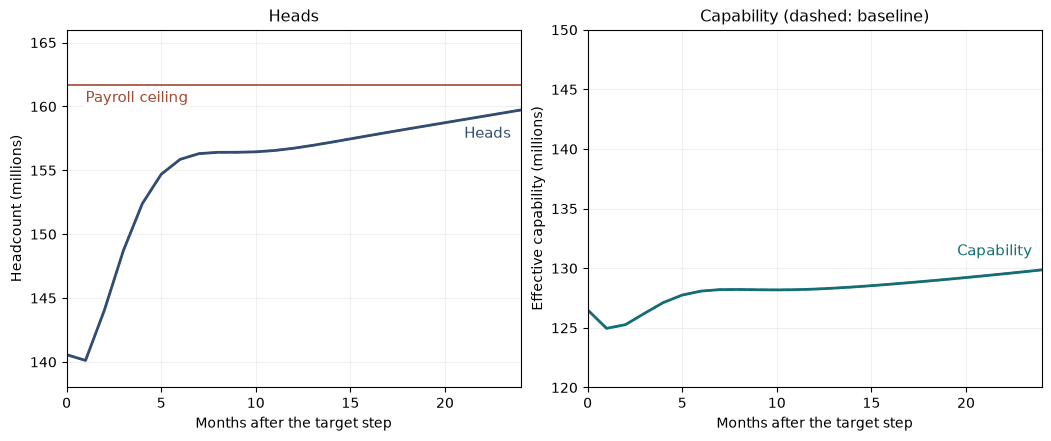

- **Rule:** Baseline
- **Target step:** 10 percent
- **Headcount, month 24 (thousand):** 159,721
- **Effective capability, month 24 (thousand):** 129,864
- **Capability per head:** 0.813
- **Hires over 24 months (thousand):** 154,441
- **Capability above baseline (thousand):** 0
- **Record, no push: employment, January 2017 (thousand):** 145,628

Capability per head = 129,864 / 159,721 = 0.813. Against the baseline under the same step, capability differs by 129,863.8 - 129,863.8 = 0.0 thousand, while headcount differs by 159,720.6 - 159,720.6 = 0.0 thousand. A hiring target acts on the first stock and the rules differ mostly in the second. Capability is a construct of the model, inferred from a fit to a national aggregate, and the record has no column for it.

In [18]:
show(heads_vs_capability(rule='baseline', step=0.1))

**Use the idea.** Put a capability column beside the headcount column before choosing a hiring rule.

**Where the conclusion applies.** Fitted knobs are inferred from the record. The initial capability of 0.4 and the other rule settings are assumed. The conclusion fails if early leavers carry less than the average.

*Constructed example on the published public record: the model is fitted to it, the rules are the chapter's constructed rules, and the five percent step is a constructed variant.*

Every setting the interactive reader offers for this demonstration:

In [19]:
sweep(heads_vs_capability, [('rule', ['baseline', 'hire_harder', 'retain', 'shorten_ramp']), ('step', [0.05, 0.1])])

- **rule = baseline, step = 0.05**: Rule Baseline; Target step 5 percent; Headcount, month 24 (thousand) 152,452; Effective capability, month 24 (thousand) 124,328; Capability per head 0.816; Hires over 24 months (thousand) 139,512; Capability above baseline (thousand) 0; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = baseline, step = 0.1**: Rule Baseline; Target step 10 percent; Headcount, month 24 (thousand) 159,721; Effective capability, month 24 (thousand) 129,864; Capability per head 0.813; Hires over 24 months (thousand) 154,441; Capability above baseline (thousand) 0; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = hire_harder, step = 0.05**: Rule Hire harder; Target step 5 percent; Headcount, month 24 (thousand) 152,743; Effective capability, month 24 (thousand) 124,721; Capability per head 0.817; Hires over 24 months (thousand) 139,730; Capability above baseline (thousand) 392; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = hire_harder, step = 0.1**: Rule Hire harder; Target step 10 percent; Headcount, month 24 (thousand) 159,933; Effective capability, month 24 (thousand) 130,302; Capability per head 0.815; Hires over 24 months (thousand) 154,486; Capability above baseline (thousand) 438; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = retain, step = 0.05**: Rule Retain; Target step 5 percent; Headcount, month 24 (thousand) 152,463; Effective capability, month 24 (thousand) 126,896; Capability per head 0.832; Hires over 24 months (thousand) 122,981; Capability above baseline (thousand) 2,567; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = retain, step = 0.1**: Rule Retain; Target step 10 percent; Headcount, month 24 (thousand) 159,730; Effective capability, month 24 (thousand) 132,548; Capability per head 0.830; Hires over 24 months (thousand) 136,703; Capability above baseline (thousand) 2,684; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = shorten_ramp, step = 0.05**: Rule Shorten ramp; Target step 5 percent; Headcount, month 24 (thousand) 152,473; Effective capability, month 24 (thousand) 136,755; Capability per head 0.897; Hires over 24 months (thousand) 130,726; Capability above baseline (thousand) 12,426; Record, no push: employment, January 2017 (thousand) 145,628
- **rule = shorten_ramp, step = 0.1**: Rule Shorten ramp; Target step 10 percent; Headcount, month 24 (thousand) 159,736; Effective capability, month 24 (thousand) 143,217; Capability per head 0.897; Hires over 24 months (thousand) 144,574; Capability above baseline (thousand) 13,353; Record, no push: employment, January 2017 (thousand) 145,628

## 2. Two surveys, one identity

*Do hires less separations match the change in employment?*

In the model headcount has exactly the hire, quit and layoff flows, so the identity holds to floating point. In the record two samples count different things, so a small gap remains.

    Employment change equals hires minus separations.

**Symbols and inputs.** Hires and separations are thousand persons a month from JOLTS. Employment is thousand persons from CES. The gap is cumulative net hires minus the employment change.

**Predict first.** Over 2015 to 2019, is the gap between the two surveys under one percent of the change?

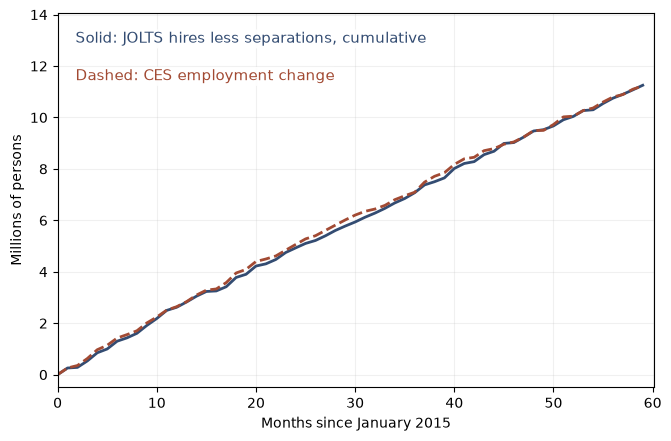

- **Window:** January 2015 to December 2019
- **Hires less separations (thousand):** 11,253
- **Employment change (thousand):** 11,226
- **Gap (thousand):** 27
- **Gap share of the change (percent):** 0.24
- **Model identity residual (thousand persons):** 0.000

Hires less separations come to 11,253 thousand and employment rises 11,226 thousand, so the gap is 11,253 - 11,226 = 27 thousand, and 27 / 11,226 = 0.24 percent of the change. Two surveys count different samples, so the identity holds in the record only approximately. In the model headcount has exactly those flows, and the residual over 59 months is 0.000.

In [20]:
show(identity(end='2019-12'))

**Use the idea.** Run the identity on a record before trusting one series as a check on the other.

**Where the conclusion applies.** The window starts in January 2015 and counts flows from February. The gap is noise only if the surveys share a definition of a job.

*Constructed example on the published public record: the window ends are constructed choices on the published data.*

Every setting the interactive reader offers for this demonstration:

In [21]:
sweep(identity, [('end', ['2016-12', '2017-12', '2018-12', '2019-12'])])

- **end = 2016-12**: Window January 2015 to December 2016; Hires less separations (thousand) 4,749; Employment change (thousand) 4,840; Gap (thousand) (-91); Gap share of the change (percent) -1.88; Model identity residual (thousand persons) 0.000
- **end = 2017-12**: Window January 2015 to December 2017; Hires less separations (thousand) 6,849; Employment change (thousand) 6,955; Gap (thousand) (-106); Gap share of the change (percent) -1.52; Model identity residual (thousand persons) 0.000
- **end = 2018-12**: Window January 2015 to December 2018; Hires less separations (thousand) 9,238; Employment change (thousand) 9,241; Gap (thousand) (-3); Gap share of the change (percent) -0.03; Model identity residual (thousand persons) 0.000
- **end = 2019-12**: Window January 2015 to December 2019; Hires less separations (thousand) 11,253; Employment change (thousand) 11,226; Gap (thousand) 27; Gap share of the change (percent) 0.24; Model identity residual (thousand persons) 0.000

## 3. A fit within tolerance, a holdout outside it

*Where does the fitted model sit against the record before, during and after the fit window?*

The model carries a trend and two loops through 2020 and 2021 with nothing in it that knows the pandemic happened, so it meets the holdout on the wrong side of the record.

    'fit_window': 0.0238, 'tolerance': 0.08, 'holdout': 0.1021}

**Symbols and inputs.** Hires and quits are JOLTS thousand persons a month. The error at a month is model / record - 1. The fit window is the first 60 months, the holdout is the last 36.

**Predict first.** In January 2022, is the model's quit count above or below the record, and by about how much?

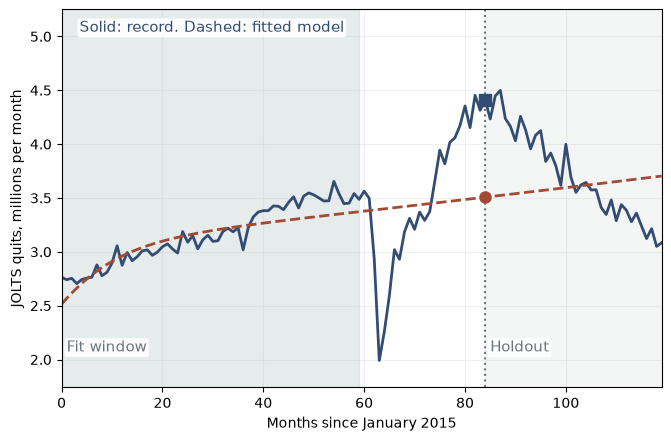

- **Series:** quits
- **Month:** January 2022
- **Model (thousand):** 3,507
- **Record (thousand):** 4,413
- **Model against record (percent):** (-20.5)
- **Fit window error (percent):** 3.15
- **Holdout error (percent):** 10.72

At January 2022 the model reads 3,507 against a record of 4,413: 3,507 / 4,413 - 1 = (-0.205), which is (-20.5) percent. The mean absolute percentage error is 3.15 percent over the 60 fit months and 10.72 percent over the 36 holdout months. The fitted values are inferred from the fit window, and the model runs through 2020 with nothing in it that knows what happened.

In [22]:
show(holdout_miss(series='quits', month=84))

**Use the idea.** Quote the holdout error beside the fit error, and the sign of the miss.

**Where the conclusion applies.** Fitted values are inferred from 2015 to 2019. The holdout fails when the world breaks the structure, which is a judgment for people who run the system.

*Constructed example on the published public record: the fitted path is inferred from it, and the months shown are constructed picks.*

Every setting the interactive reader offers for this demonstration:

In [23]:
sweep(holdout_miss, [('series', ['hires', 'quits']), ('month', [0, 59, 84, 119])])

- **series = hires, month = 0**: Series hires; Month January 2015; Model (thousand) 4,639; Record (thousand) 5,061; Model against record (percent) (-8.3); Fit window error (percent) 2.38; Holdout error (percent) 10.21
- **series = hires, month = 59**: Series hires; Month December 2019; Model (thousand) 5,868; Record (thousand) 5,951; Model against record (percent) (-1.4); Fit window error (percent) 2.38; Holdout error (percent) 10.21
- **series = hires, month = 84**: Series hires; Month January 2022; Model (thousand) 6,102; Record (thousand) 6,431; Model against record (percent) (-5.1); Fit window error (percent) 2.38; Holdout error (percent) 10.21
- **series = hires, month = 119**: Series hires; Month December 2024; Model (thousand) 6,443; Record (thousand) 5,292; Model against record (percent) 21.8; Fit window error (percent) 2.38; Holdout error (percent) 10.21
- **series = quits, month = 0**: Series quits; Month January 2015; Model (thousand) 2,515; Record (thousand) 2,764; Model against record (percent) (-9.0); Fit window error (percent) 3.15; Holdout error (percent) 10.72
- **series = quits, month = 59**: Series quits; Month December 2019; Model (thousand) 3,372; Record (thousand) 3,487; Model against record (percent) (-3.3); Fit window error (percent) 3.15; Holdout error (percent) 10.72
- **series = quits, month = 84**: Series quits; Month January 2022; Model (thousand) 3,507; Record (thousand) 4,413; Model against record (percent) (-20.5); Fit window error (percent) 3.15; Holdout error (percent) 10.72
- **series = quits, month = 119**: Series quits; Month December 2024; Model (thousand) 3,704; Record (thousand) 3,085; Model against record (percent) 20.1; Fit window error (percent) 3.15; Holdout error (percent) 10.72

## 4. Which parameter decides capability

*Which assumption moves month 24 capability most, and does that depend on where the others sit?*

The ramp sets how fast hires become seasoned, which the capability stock reads directly. Gap-closing time changes how fast requisitions open, which the headcount rule largely offsets.

    # ramp_time 22410

**Symbols and inputs.** Each parameter is swung across a range somebody would defend. Capability is thousand effective persons at month 24 under a ten percent target step.

**Predict first.** With the others at their midpoints, does ramp time or gap-closing time move capability more?

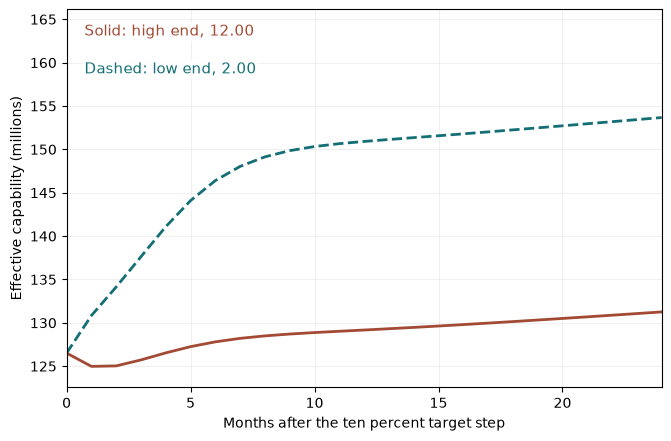

- **Parameter swung:** ramp_time
- **Range swung:** 2.00 to 12.00
- **Others held at:** midpoints of their ranges
- **Capability at month 24, low end (thousand):** 153,668
- **Capability at month 24, high end (thousand):** 131,257
- **Swing (thousand):** 22,410

Swing = |high end - low end| = |131,257.5 - 153,667.7| = 22,410.2 thousand effective persons at month 24. This is one parameter at a time with the others held where stated, over a range somebody would defend, not a confidence interval. The ramp is a fitted value that the record barely constrains, so a ranking that puts it first is a pointer to what to measure.

In [24]:
show(capability_swing(parameter='ramp_time', hold='midpoint'))

**Use the idea.** Measure the parameter at the top of the ranking before choosing a rule.

**Where the conclusion applies.** One parameter at a time, chosen ranges, and a structure that failed its holdout. The ranking changes with the hold setting.

*Constructed example on the published public record: ranges are the chapter's chosen ranges, and the fitted-values hold is a constructed variant of the midpoint hold.*

Every setting the interactive reader offers for this demonstration:

In [25]:
sweep(capability_swing, [('parameter', ['ramp_time', 'initial_capability', 'gap_closing_time', 'quit_sensitivity']), ('hold', ['midpoint', 'fitted'])])

- **parameter = ramp_time, hold = midpoint**: Parameter swung ramp_time; Range swung 2.00 to 12.00; Others held at midpoints of their ranges; Capability at month 24, low end (thousand) 153,668; Capability at month 24, high end (thousand) 131,257; Swing (thousand) 22,410
- **parameter = ramp_time, hold = fitted**: Parameter swung ramp_time; Range swung 2.00 to 12.00; Others held at the fitted or assumed values; Capability at month 24, low end (thousand) 153,602; Capability at month 24, high end (thousand) 129,864; Swing (thousand) 23,738
- **parameter = initial_capability, hold = midpoint**: Parameter swung initial_capability; Range swung 0.25 to 0.60; Others held at midpoints of their ranges; Capability at month 24, low end (thousand) 135,127; Capability at month 24, high end (thousand) 147,087; Swing (thousand) 11,959
- **parameter = initial_capability, hold = fitted**: Parameter swung initial_capability; Range swung 0.25 to 0.60; Others held at the fitted or assumed values; Capability at month 24, low end (thousand) 120,854; Capability at month 24, high end (thousand) 140,575; Swing (thousand) 19,721
- **parameter = gap_closing_time, hold = midpoint**: Parameter swung gap_closing_time; Range swung 1.50 to 6.00; Others held at midpoints of their ranges; Capability at month 24, low end (thousand) 141,950; Capability at month 24, high end (thousand) 140,587; Swing (thousand) 1,363
- **parameter = gap_closing_time, hold = fitted**: Parameter swung gap_closing_time; Range swung 1.50 to 6.00; Others held at the fitted or assumed values; Capability at month 24, low end (thousand) 130,302; Capability at month 24, high end (thousand) 128,631; Swing (thousand) 1,671
- **parameter = quit_sensitivity, hold = midpoint**: Parameter swung quit_sensitivity; Range swung 0.50 to 3.00; Others held at midpoints of their ranges; Capability at month 24, low end (thousand) 141,628; Capability at month 24, high end (thousand) 141,122; Swing (thousand) 506
- **parameter = quit_sensitivity, hold = fitted**: Parameter swung quit_sensitivity; Range swung 0.50 to 3.00; Others held at the fitted or assumed values; Capability at month 24, low end (thousand) 131,495; Capability at month 24, high end (thousand) 128,589; Swing (thousand) 2,906

## Exercises

Try each before opening the answer. The settings above let you check the numbers.

### Exercise 1

If capability is 130,000 and headcount is 160,000, what is capability per head?

<details><summary>Answer</summary>

130,000 / 160,000 = 0.8125, about 0.813.

</details>

### Exercise 2

If cumulative net hires are 11,000 and employment rises 10,900, what share of the change is the gap?

<details><summary>Answer</summary>

11,000 - 10,900 = 100, and 100 / 10,900 = 0.0092, about 0.9 percent.

</details>

### Exercise 3

If the model reads 3,500 and the record 4,400, what is the error as a percentage?

<details><summary>Answer</summary>

3,500 / 4,400 - 1 = -0.2045, about -20.5 percent.

</details>

---

From *Systems Thinking with AI* by Jason Karpeles. Copyright Jason Karpeles. All rights reserved.

Interactive companion: https://karpeles.com/companions/systems-thinking-with-ai/